# **Три LM-архитектуры — три пространства**
Какой кодер, такой и result: как геометрия эмбеддингов следует из маски внимания

При проектировании эксперимента мы тестируем разные архитектуры. В прикладном применении нам важен выход и побочные характеристики (скорость, поддержка фреймворками, современность), а вот в теоретическом — мы пробуем найти интересный результат.

Как не найти его там, где нет, сравнивая модели разных архитектур? Что существует в архитектуре по её определению? Этим чудесным вопросам и посвящена статья. 

> Привет, читатель! Меня зовут Сабрина, и это очередной туториал из серии про то, как заглядывать моделям внутрь. Я пишу эту статью в месте, где многие хайкают. И как у хорошего хайка — у этой статьи будет несколько view points! : ) 

**Что будет:**

1. **Теория трёх масок** — одна формула внимания, три способа её замаскировать.
2. **Информативность токенов** — какие позиции что видели и сколько весят.
3. **Геометрия** (основная часть) — анизотропия, спектр, participation ratio, CKA.
4. **Вывод** — а зачем это на практике.
5. **Шпаргалка и грабли** — что не делать и куда смотреть.

Рассмотрим четыре модели, малюсенькие, всё посчитается на CPU за несколько минут и, как всегда, будет в ноутбуке. Берите воду, кофе, снеки и вперед!

## **Рассматриваемые архитектуры**

Классические архитектуры языковых моделей обычно делят на три семейства: encoder-only, decoder-only и encoder-decoder. На схемах (и мемах) они выглядят по-разному и решают разные задачи, но внутри они, вообще говоря, устроены очень похоже. 


## **Общее: Attention**
Для каждого семейства основной вычислительный механизм — это attention с фиксированной и знакомой формулой, вида:

$$\text{Attn}(Q, K, V) = \operatorname{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}} + M\right) V$$

Здесь $Q = XW_Q$, $K = XW_K$, $V = XW_V$ — линейные проекции входа, а $M$ — **аддитивная маска**: матрица из нулей и $-\infty$. Ноль означает «смотреть можно», $-\infty$ после softmax превращается в нулевой вес и означает «смотреть нельзя».

### **Сноска: если формула вам не знакома или забылась**

Рассмотрим классический пример, когда на вход пришло предложение «the cat sat», и каждый токен уже превратился в вектор $x_1, x_2, x_3$. Слой внимания делает из каждого вектора три роли:

- $q_i = x_i W_Q$ — **запрос**: «что я ищу в контексте»;
- $k_i = x_i W_K$ — **ключ**: «по какому признаку меня можно найти»;
- $v_i = x_i W_V$ — **значение**: «что я отдам тому, кто меня нашёл».

**Шаг 1. Совместимость.** Скалярное произведение каждого запроса с каждым ключом: $s_{ij} = \langle q_i, k_j \rangle$. Получается матрица $n \times n$ — «насколько токен $i$ заинтересован в токене $j$».

**Шаг 2. Масштаб.** Делим на $\sqrt{d_k}$. Без этого при больших $d_k$ скалярные произведения растут по величине, softmax уходит в насыщение (один вес ≈ 1, остальные ≈ 0), а градиенты умирают.

**Шаг 3. Маска.** Прибавляем $M$. Ноль ничего не меняет; $-\infty$ гарантирует нулевой вес после экспоненты, потому что $e^{-\infty} = 0$.

**Шаг 4. Softmax по строке.** Каждая строка превращается в распределение: веса неотрицательны и суммируются в единицу. Ключевое слово — **по строке**: токен $i$ распределяет свою единицу внимания между всеми доступными ему $j$.

**Шаг 5. Взвешенная сумма.** $h_i = \sum_j a_{ij} v_j$ — новое представление токена есть смесь значений всех, на кого он посмотрел, с весами из шага 4.

Дальше это делается параллельно $H$ раз (многоголовость), результаты склеиваются и проходят ещё одну линейную проекцию, а вокруг всего — residual-связь, нормализация и MLP. Эффекты, которые мы будем эксплуатировать в туториале расположены в шагах 3–5.

### 
Заметим, что:

1. **Строка softmax обязана просуммироваться в единицу.** Голова не умеет «не смотреть никуда»: если ей на этом шаге ничего не нужно, массу внимания всё равно придётся куда-то положить.
2. **Маска стоит внутри softmax, а не после него.** Запрет «смотреть вперёд» — это не обнуление весов задним числом, а перераспределение: оставшиеся веса нормируются заново. 

Обобщая, можно сказать, что в основном в семействах меняется то каким токенам разрешено видеть какие другие токены и откуда берётся контекст для внимания. Иными словами, изначально геометрически мы сводим (грубо, но право имеем) архитектурные различия к двум вещам: 
- маске внимания
- источнику (Q, K, V)

| Архитектура | $M_{ij}$ | Источник $Q$ | Источник $K, V$ |
|---|---|---|---|
| **encoder-only** (BERT) | $0$ везде | сам слой | сам слой |
| **decoder-only** (GPT-2) | $0$ при $j \le i$; $-\infty$ при $j > i$ | сам слой | сам слой |
| **enc-dec: encoder** (T5, BART) | $0$ везде | encoder | encoder |
| **enc-dec: self-attn декодера** | треугольная | decoder | decoder |
| **enc-dec: cross-attention** | $0$ везде | **decoder** | **encoder** |

> Спасибо LLM за таблицы, которые учишься делать, чтобы представлять информацию компактно и сжато. 

Из этой таблицы мы можем достать три важных для нас сейчас факта:

**Следствие 1. Кто что видел.** В каузальной модели (decoder) представление токена на позиции $i$ — функция *только* префикса $x_{\le i}$. Формально:

$$h_i^{\text{causal}} = f(x_1, \dots, x_i), \qquad h_i^{\text{bidir}} = f(x_1, \dots, x_n)$$

Тогда по построению видим: токены внутри **одной** последовательности несут **разный объём контекста**: первый видел одно слово, последний — всё предложение.

**Следствие 2. Где «смысл целого».** У encoder-only он размазан по всем позициям (плюс `[CLS]`, который *обучен* агрегировать — но обучен под задачу Next Sentence Prediction). У decoder-only — строго в последнем токене, единственном, кто видел всё. У encoder-decoder — в выходе энкодера; а вот состояние декодера — это уже не «смысл входа», а «состояние генерации».

**Следствие 3. Сколько пространств.** Одно, одно и **два**. У encoder-decoder пространство энкодера и пространство декодера обучались под разные роли: у них разные нормы, разные базисы и разный смысл координат. 

Каждое следствие порождает геометрические нюансы и беды. На них мы и будем смотреть. 

### **Различие: Objective**

Окей, маской мы завладели, но это только половина необходимого. Справедливо заметить, что модели по постановке учатся разным задачам:

- **MLM** (BERT, encoder): маскируем случайные токены и восстанавливаем их из **двустороннего** контекста. Каждая позиция обязана быть самодостаточной — из неё должны восстановить конкретное слово. Это давление «размазывает» информацию по всем позициям и по многим направлениям.

- **CLM** (GPT-2, decoder): предсказываем следующий токен. Оптимизируется, по сути, **одна** функция — распределение над словарём на выходе. Пространство схлопывается вдоль направлений, полезных для next-token-предсказания; всё, что для этого не нужно, сжимается. Как мы увидим, схлопывание получается буквальным.

- **Span corruption** (T5, encoder-decoder) и **denoising / text infilling** (BART, encoder-decoder): портим текст — выкидываем куски — и восстанавливаем его целиком. Энкодер работает двунаправленно, но его выход должен быть удобен для **потребления декодером** через cross-attention. Это отдельное, третье давление на геометрию, и у T5 с BART оно реализовано по-разному.

### **Напоминание постановок задач.** 


- **MLM** (BERT) — случайные 15% токенов по двустороннему контексту (из них 80% заменяются на `[MASK]`, 10% на случайный токен, 10% остаются как есть). 

Пример: `The doctor told the [MASK] that the surgery was successful.` — `patient`. 

- **NSP** (BERT) — задача идут ли два куска текста подряд  

Пример: `[CLS] The doctor told the patient … [SEP] The surgery took three hours. [SEP]` — `IsNext` 

- **CLM** (GPT-2) - прогнозирование следующего токена по левому контексту. 

Пример: `The doctor told the` → `patient`.

- **Span corruption** (T5) - обучение через выкинутые спаны, каждый под своим sentinel-токеном. 

Пример: вход `The doctor told the <X> that the surgery <Y> successful.` — таргет `<X> patient <Y> was <Z>` 

- **Denoising / text infilling** (BART) — задача восстановить  текст целиком после произвольной порчи: спаны схлопываются в один `<mask>`, предложения переставляются, токены удаляются. 

Пример: `The doctor <mask> the surgery was successful.` — полный оригинал

Потом это, конечно, видоизменилось (ELECTRA, DeBERTa, ALBERT — уже имеют поправки разной силы в постановке). Но основа до сих пор такая. 

###
Запомним, что MLM требует, чтобы **каждая** позиция была самодостаточной — из неё восстанавливают конкретное слово. CLM оптимизирует **одну** позицию под одно распределение над словарём. Span corruption и denoising делают выход энкодера удобным не для классификатора, а **для чтения декодером** через cross-attention. Это, вообще говоря, три разных давления на геометрию. 

Отдельно нам также важен будет `[CLS]`: он единственная позиция BERT, которую явно учили агрегировать, — но учили под NSP, то есть под «идут ли эти два куска подряд», а это в основном решается совпадением темы. 

## **К практике готовы**

Итак, из абзацев выше мы увидели, что **маска определяет, какой токен куда смотрит, а objective давит на форму, которую может принять облако токенов**. Три факта из определения маски, три задачи под семейства, а мы всё ещё ничего не проверили. Чешем руки в предвкушении и смотрим эксперимент. 

## **Setup**

Ноутбук писался на маке (MPS), тестировался на CPU. Все модели маленькие, полный прогон занимает мало минут.

Данные: **English Web Treebank** — настоящие предложения для качественных экспериментов, и **ag_news** — тексты для облаков токенов и для CKA.

In [1]:
# ── Setup: все импорты ноутбука живут здесь ──────────────────────────
import warnings
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.decomposition import PCA
from transformers import AutoModel, AutoTokenizer, T5EncoderModel

warnings.filterwarnings("ignore")
import transformers

transformers.logging.set_verbosity_error()

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
plt.rcParams.update({"font.size": 10, "figure.dpi": 110})


MARKERS = ["o", "s", "^", "D", "v", "P"]
CAUSAL_STACKS = {"GPT-2 (dec-only)", "T5-dec (enc-dec)", "BART-dec (enc-dec)"}


def style(label):
    """Пунктир для каузального типа, сплошная линия для двунаправленного."""
    return "--" if label in CAUSAL_STACKS else "-"

print("torch:", torch.__version__, "| transformers:", transformers.__version__)

torch: 2.8.0 | transformers: 5.10.2


### **Данные**

English Web Treebank —  английские тексты из веба (блоги, отзывы, письма, форумы) с синтаксической разметкой, сделанной людьми. Из него мы возьмём и предложения для экспериментов.

In [2]:
import random
from datasets import load_dataset

UD_NAME, UD_CONFIG = "universal-dependencies/universal_dependencies", "en_ewt"


def load_ud(split="train"):
    return load_dataset(UD_NAME, UD_CONFIG, split=split)


def causal_test_sentence(ud, target_chars=70):
    """Одно предложение для матрицы влияния.

    Выбор детерминированный — берём ближайшее по длине к target_chars,
    чтобы картинка не менялась от запуска к запуску.
    """
    candidates = [t for t in ud["text"] if 40 <= len(t) <= 110 and t.count(" ") >= 8]
    return min(candidates, key=lambda t: abs(len(t) - target_chars))


UD = load_ud()

CAUSAL_TEST_SENTENCE = causal_test_sentence(UD)

print(f"Предложений в корпусе: {len(UD)}")
print(f"\nПример:\n  {CAUSAL_TEST_SENTENCE!r}")


Предложений в корпусе: 12544

Пример:
  'You wonder if he was manipulating the market with his bombing targets.'


### **Модели**

| Семейство | Модель | Слои | $D$ | Внимание | Objective |
|---|---|---|---|---|---|
| encoder-only | `bert-base-uncased` | 12 | 768 | двунаправленное | MLM + NSP |
| decoder-only | `gpt2` | 12 | 768 | каузальное | CLM |
| encoder-decoder | `facebook/bart-base` | 6 + 6 | 768 | enc: двунапр. / dec: кауз. + cross | denoising (text infilling) |
| encoder-decoder | `t5-small` | 6 + 6 | 512 | enc: двунапр. / dec: кауз. + cross | span corruption |

Список моделей, которые будут нашими объектами анализа выше. Он собран так, чтобы:
- покрыть все три семейства в сопоставимых размерностях и при сопоставимом числе голов (первые три);
- обеспечить контроль над другими свободными параметрами внутри encoder-decoder (у T5: RMSNorm без сдвига, relative position bias, span corruption, у BART обычный LayerNorm, выученные абсолютные позиции, denoising-objective)

Резонный вопрос: контроль внутри encoder-decoder есть (две модели), а где контроль для encoder-only и для decoder-only? Мы схитрим, и достанем их отсюда же:

- **Контроль для encoder-only — это энкодеры T5 и BART.** Двунаправленных моделей у нас три: BERT, энкодер T5, энкодер BART. 

- **Контроль для decoder-only — это декодеры T5 и BART.** Каузальных моделей у нас тоже три: GPT-2, декодер T5, декодер BART. 

Они различаются размерностью, глубиной, objective, токенизатором и корпусом претрейна — то есть дают в целом достаточную вариативность.


> **Примечание техническое.** В `transformers` 5.x по умолчанию используется SDPA-реализация внимания, и при ней `output_attentions=True` возвращает **пустой список** (бага). Для любого анализа внимания нужен `attn_implementation="eager"`. 


In [3]:
# ── Шесть типов: encoder-only, decoder-only и обе половины двух encoder-decoder ──
MODEL_IDS = {                      # энкодерные части: «эмбеддинг текста» живёт здесь
    "BERT (enc-only)": "bert-base-uncased",
    "GPT-2 (dec-only)": "gpt2",
    "T5-enc (enc-dec)": "t5-small",
    "BART-enc (enc-dec)": "facebook/bart-base",
}
S2S_IDS = {                        # декодерные части тех же двух encoder-decoder
    "T5-dec (enc-dec)": "t5-small",
    "BART-dec (enc-dec)": "facebook/bart-base",
}
ALL_LABELS = list(MODEL_IDS) + list(S2S_IDS)


def shift_right(ids, model):
    """Teacher forcing: декодер читает тот же текст, сдвинутый на одну позицию."""
    out = ids.new_zeros(ids.shape)
    out[:, 1:] = ids[:, :-1].clone()
    out[:, 0] = model.config.decoder_start_token_id
    return out


class DecoderStack:
    """Декодер с интерфейсом обычной энкодерной модели.

    Вызов прогоняет полную seq2seq-модель — декодер без энкодера не
    существует — и возвращает декодерную сторону выхода. Поэтому весь
    остальной код (матрицы влияния, насыщение, облака, CKA) работает
    с декодером без единой правки.
    """

    def __init__(self, model):
        self.model = model
        self.config = model.config

    def parameters(self):
        return self.model.get_decoder().parameters()

    def __call__(self, input_ids, attention_mask=None,
                 output_hidden_states=False, output_attentions=False):
        with torch.no_grad():
            out = self.model(
                input_ids=input_ids, attention_mask=attention_mask,
                decoder_input_ids=shift_right(input_ids, self.model),
                output_hidden_states=output_hidden_states,
                output_attentions=output_attentions,
            )
        return SimpleNamespace(
            last_hidden_state=out.last_hidden_state,          # декодерная сторона
            hidden_states=out.decoder_hidden_states,
            attentions=out.decoder_attentions,                # self-attention декодера
            cross_attentions=out.cross_attentions,
            encoder_last_hidden_state=out.encoder_last_hidden_state,
            encoder_attentions=out.encoder_attentions,
        )


TOK, MODEL, S2S = {}, {}, {}

for label, mid in MODEL_IDS.items():
    tok = AutoTokenizer.from_pretrained(mid)
    if tok.pad_token is None:      # у GPT-2 нет pad-токена из коробки
        tok.pad_token = tok.eos_token
    TOK[label] = tok
    # У обеих encoder-decoder моделей берём только энкодер: это та часть,
    # которая и производит «эмбеддинг текста».
    # eager attention: под SDPA output_attentions возвращает пустой список
    # (примечание выше), а на сами числа выбор реализации не влияет.
    if mid.startswith("t5"):
        model = T5EncoderModel.from_pretrained(mid, attn_implementation="eager")
    elif "bart" in mid:
        model = AutoModel.from_pretrained(mid, attn_implementation="eager").encoder
    else:
        model = AutoModel.from_pretrained(mid, attn_implementation="eager")
    MODEL[label] = model.eval()

for label, mid in S2S_IDS.items():
    S2S[label] = AutoModel.from_pretrained(mid, attn_implementation="eager").eval()
    MODEL[label] = DecoderStack(S2S[label])
    TOK[label] = AutoTokenizer.from_pretrained(mid)


def _cfg(cfg, *names):
    for n in names:
        if getattr(cfg, n, None) is not None:
            return getattr(cfg, n)
    return None


def _first_token(label):
    """Что реально лежит на позиции 0: служебный токен или обычное слово."""
    if label in S2S_IDS:
        return TOK[label].convert_ids_to_tokens([S2S[label].config.decoder_start_token_id])[0]
    ids = TOK[label](CAUSAL_TEST_SENTENCE, return_tensors="pt")["input_ids"]
    return TOK[label].convert_ids_to_tokens(ids[0][:1])[0]


rows = []
for label in ALL_LABELS:
    cfg, is_dec = MODEL[label].config, label in S2S_IDS
    rows.append([
        label, (S2S_IDS if is_dec else MODEL_IDS)[label],
        _cfg(cfg, "decoder_layers", "num_decoder_layers") if is_dec
        else _cfg(cfg, "num_hidden_layers", "n_layer", "num_layers", "encoder_layers"),
        _cfg(cfg, "hidden_size", "n_embd", "d_model"),
        _cfg(cfg, "decoder_attention_heads", "num_heads") if is_dec
        else _cfg(cfg, "num_attention_heads", "n_head", "num_heads", "encoder_attention_heads"),
        f"{sum(p.numel() for p in MODEL[label].parameters()) / 1e6:.0f}M",
        len(TOK[label]),
        _first_token(label),
    ])

print(
    pd.DataFrame(
        rows,
        columns=["Тип", "Модель", "Слоёв", "D", "Голов", "Параметров (взятая часть)",
                 "Словарь", "Что на позиции 0"],
    ).to_string(index=False)
)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/51 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

               Тип             Модель  Слоёв   D  Голов Параметров (взятая часть)  Словарь Что на позиции 0
   BERT (enc-only)  bert-base-uncased     12 768     12                      109M    30522            [CLS]
  GPT-2 (dec-only)               gpt2     12 768     12                      124M    50257              You
  T5-enc (enc-dec)           t5-small      6 512      8                       35M    32100             ▁You
BART-enc (enc-dec) facebook/bart-base      6 768     12                       82M    50265              <s>
  T5-dec (enc-dec)           t5-small      6 512      8                       42M    32100            <pad>
BART-dec (enc-dec) facebook/bart-base      6 768     12                       96M    50265             </s>


> Колонка «Параметров» считает только ту часть, которую мы реально анализируем: для T5 и BART это **энкодер**, а не вся seq2seq-модель. Поэтому числа меньше тех, что указаны на карточках моделей.

Соблазн потрогать декодеры мы, конечно, не сдерживаем — но декодер не запускается так же просто, как энкодер. Энкодеру хватает одного входа: подали текст, забрали состояния. Декодеру нужны два сразу — что прочитал энкодер (это придёт через cross-attention) и `decoder_input_ids`, то есть «что уже сгенерировано». Без второго forward просто не посчитается.

> Интуиция «энкодер сжал текст в один вектор, декодер его принял» — из seq2seq на RNN. В трансформере никакого одного вектора нет: декодер вычитывает **все** выходные векторы энкодера через cross-attention, заново на каждом своём слое и на каждом шаге генерации, и параллельно смотрит на то, что сам уже написал.

Значит, состояния «для текста X» у декодера не существует — есть состояние «для пары (вход X, история Y)», и историю придётся выбрать нам. Берём самый прозрачный вариант, teacher forcing: тот же текст, сдвинутый на одну позицию вправо.

Технически мы заворачиваем декодер в обёртку с тем же интерфейсом, что у обычной модели: вызвали — получили `last_hidden_state`, `hidden_states`, `attentions`. После этого весь остальной код ноутбука работает с декодерными частями просто удобнее.

## **Часть 1. Проверим маску**

Раз мы сказали, что attention общий, но разный, покажем это — проверим Attention **интервенцией** (проще говоря — вмешательством). 

Как:
Берём предложение. Портим токен на позиции $j$ (заменяем на `[UNK]`). Смотрим, насколько изменилось скрытое состояние на **каждой** позиции $i$:

$$\text{Influence}[i, j] = \bigl\| h_i(x) - h_i(x_{j \to \text{UNK}}) \bigr\|_2$$

Это матрица $n \times n$. Что мы ожидаем:

- когда модель **двунаправленная**, порча любого токена меняет всё 
- когда модель **каузальная**, порча токена $j$ физически не может повлиять на позиции $i < j$ ($j$ зависит от прошлых, а прошлые не менялись), отсюда верхний треугольник обязан быть **нулевым**.

In [4]:
# ── Проверка маски: портим токен j, смотрим изменение на каждой позиции i ──
def influence_matrix(model, tok, sentence):
    """Матрица (n, n): influence[i, j] = ||h_i(оригинал) - h_i(токен j испорчен)||."""
    enc = tok(sentence, return_tensors="pt")
    ids = enc["input_ids"]
    n = ids.shape[1]

    with torch.no_grad():
        base = model(**enc, output_hidden_states=True).hidden_states[-1][0]

    unk = tok.unk_token_id if tok.unk_token_id is not None else tok.eos_token_id
    M = np.zeros((n, n))
    for j in range(n):
        corrupted = ids.clone()
        corrupted[0, j] = unk
        enc_j = {k: (corrupted if k == "input_ids" else v) for k, v in enc.items()}
        with torch.no_grad():
            h = model(**enc_j, output_hidden_states=True).hidden_states[-1][0]
        M[:, j] = (h - base).norm(dim=-1).numpy()

    return M, tok.convert_ids_to_tokens(ids[0])


INFLUENCE = {}
for label in MODEL_IDS:
    M, toks = influence_matrix(MODEL[label], TOK[label], CAUSAL_TEST_SENTENCE)
    INFLUENCE[label] = (M, toks)
    n = M.shape[0]
    denom = n * (n - 1) / 2
    future = np.triu(M, 1).sum() / denom  # j > i : влияние будущего
    past = np.tril(M, -1).sum() / denom   # j < i : влияние прошлого
    print(f"{label:18s} среднее |Δh| от будущего = {future:8.4f} | от прошлого = {past:8.4f}")

BERT (enc-only)    среднее |Δh| от будущего =   5.7298 | от прошлого =   4.3736


GPT-2 (dec-only)   среднее |Δh| от будущего =   0.0000 | от прошлого =  40.7667
T5-enc (enc-dec)   среднее |Δh| от будущего =   0.9694 | от прошлого =   0.7509


BART-enc (enc-dec) среднее |Δh| от будущего =   1.2794 | от прошлого =   1.3181


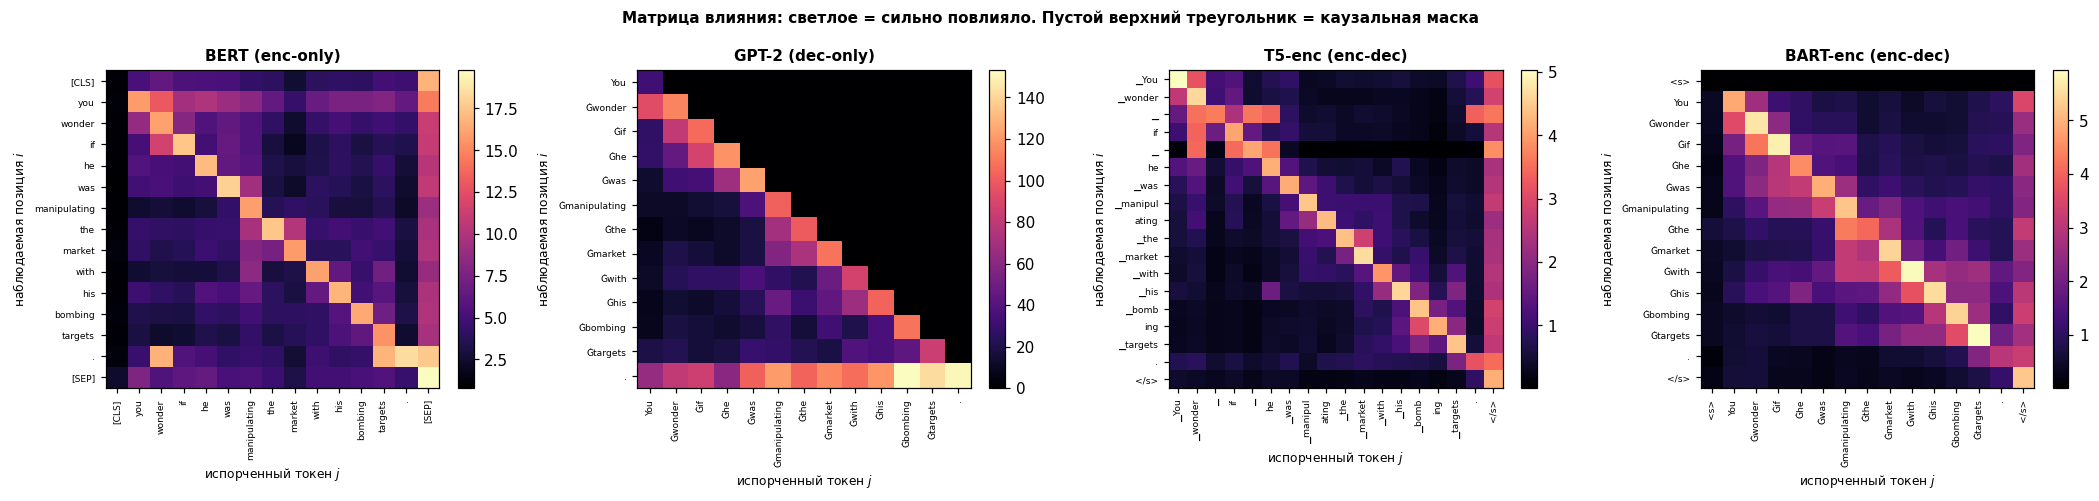

In [5]:
# ── Матрицы влияния ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(MODEL_IDS), figsize=(4.8 * len(MODEL_IDS), 4.6))

for ax, label in zip(axes, MODEL_IDS):
    M, toks = INFLUENCE[label]
    im = ax.imshow(M, cmap="magma", aspect="auto")
    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.set_xlabel("испорченный токен $j$", fontsize=8)
    ax.set_ylabel("наблюдаемая позиция $i$", fontsize=8)
    ax.set_xticks(range(len(toks)))
    ax.set_yticks(range(len(toks)))
    ax.set_xticklabels(toks, rotation=90, fontsize=6)
    ax.set_yticklabels(toks, fontsize=6)
    plt.colorbar(im, ax=ax, fraction=0.046)

fig.suptitle(
    "Матрица влияния: светлое = сильно повлияло. "
    "Пустой верхний треугольник = каузальная маска",
    fontsize=10, fontweight="bold",
)
plt.tight_layout()
plt.show()

### **Что мы видим**

- **BERT** — залитый квадрат. Влияние идёт в обе стороны, причём «из будущего» даже чуть сильнее, чем «из прошлого» (5.73 против 4.37).
- **GPT-2** — идеальный нижний треугольник. Влияние будущего — **0**. Треугольная маска в чистом виде.
- **Энкодеры T5 и BART** — снова квадраты, как и положено двунаправленным энкодерам: у обоих влияние будущего и прошлого одного порядка.

> Внимательный читатель заметит, что у GPT-2 абсолютная величина влияния прошлого — десятки, у BERT, BART, T5 — единицы. Соблазнительно прочитать это **эффектом**, но так нельзя. Почему — увидим.

### **Что у декодера в encoder-decoder (нюансы)**

Со стандартными энкодерами и декодерами всё понятно — мы сейчас меняли только вход. Сделать так в декодере мы не можем: у него **две** маски сразу. Своя история закрыта треугольником (self-attention) и вход энкодера (cross-attention). Проверим, для полноты тем же самым методом.

Матриц теперь две на модель:

- **порча входа энкодера** — меняем токен $j$ в тексте, который читает энкодер, декодерную историю не трогаем. Смотрим $\|\Delta h_i^{\text{dec}}\|$;
- **порча истории декодера** — текст на входе энкодера тот же, портим токен $j$ в том, что декодер «уже написал».

Ожидание: первая матрица — залитый квадрат (cross-attention без маски), вторая — нижний треугольник (self-attention каузален).

T5-dec (enc-dec)     порча входа энкодера : будущее =  1.5607 | прошлое =  3.2716
                     порча истории декодера: будущее =  0.0000 | прошлое =  3.6640


BART-dec (enc-dec)   порча входа энкодера : будущее = 10.3896 | прошлое = 11.7044
                     порча истории декодера: будущее =  0.0000 | прошлое = 11.0769


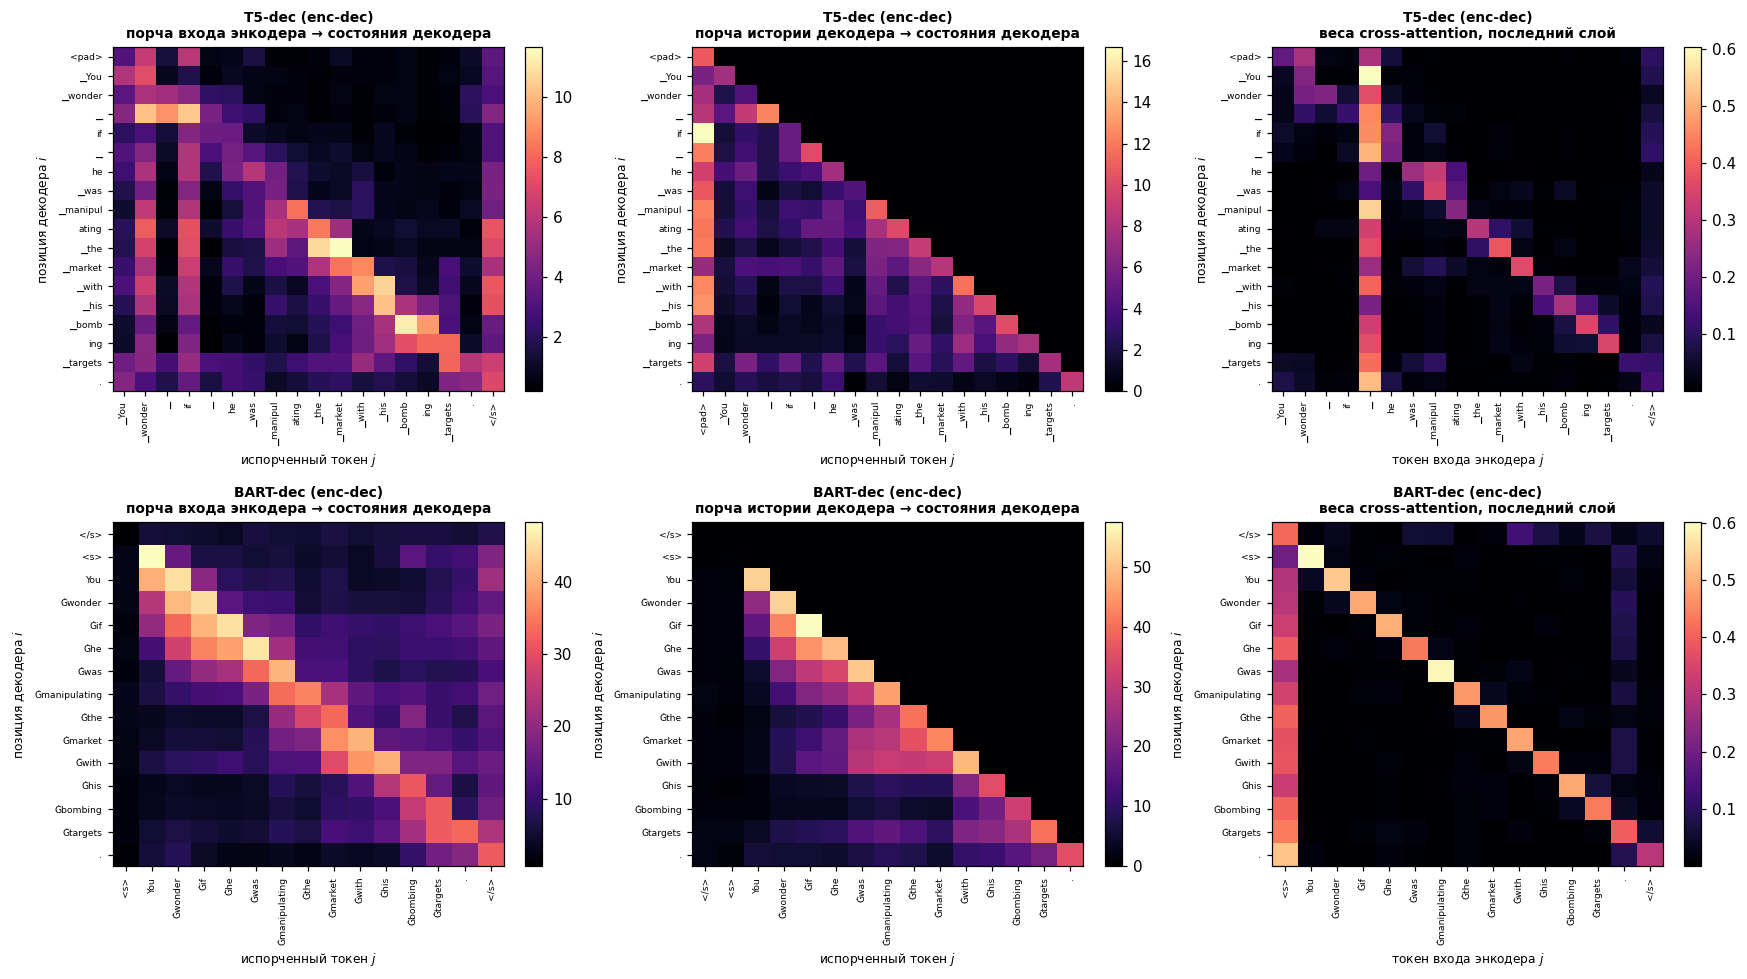

In [6]:
# ── Декодер: две маски — две матрицы влияния ─────────────────────────
def cross_attention_map(label, sentence):
    """Cross-attention последнего слоя декодера, усреднённый по головам."""
    model, tok = S2S[label], TOK[label]
    enc = tok(sentence, return_tensors="pt")
    with torch.no_grad():
        out = model(**enc, decoder_input_ids=shift_right(enc["input_ids"], model),
                    output_attentions=True)
    return out.cross_attentions[-1][0].mean(0).numpy()


def decoder_influence(label, sentence):
    """(источник, история): влияние порчи входа энкодера и истории декодера."""
    model, tok = S2S[label], TOK[label]
    enc = tok(sentence, return_tensors="pt")
    ids = enc["input_ids"]
    n = ids.shape[1]
    dec_in = shift_right(ids, model)

    def dec_states(input_ids, decoder_input_ids):
        with torch.no_grad():
            out = model(input_ids=input_ids,
                        attention_mask=torch.ones_like(input_ids),
                        decoder_input_ids=decoder_input_ids)
        return out.last_hidden_state[0]

    base = dec_states(ids, dec_in)
    unk = tok.unk_token_id if tok.unk_token_id is not None else tok.pad_token_id

    M_src, M_hist = np.zeros((n, n)), np.zeros((n, n))
    for j in range(n):
        corrupted = ids.clone()
        corrupted[0, j] = unk
        M_src[:, j] = (dec_states(corrupted, dec_in) - base).norm(dim=-1).numpy()

        hist = dec_in.clone()
        hist[0, j] = unk
        M_hist[:, j] = (dec_states(ids, hist) - base).norm(dim=-1).numpy()

    return M_src, M_hist, tok.convert_ids_to_tokens(ids[0]), tok.convert_ids_to_tokens(dec_in[0])


fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for row, label in enumerate(S2S_IDS):
    M_src, M_hist, src_toks, hist_toks = decoder_influence(label, CAUSAL_TEST_SENTENCE)
    n = M_src.shape[0]
    denom = n * (n - 1) / 2
    print(f"{label:20s} порча входа энкодера : будущее = {np.triu(M_src, 1).sum() / denom:7.4f}"
          f" | прошлое = {np.tril(M_src, -1).sum() / denom:7.4f}")
    print(f"{'':20s} порча истории декодера: будущее = {np.triu(M_hist, 1).sum() / denom:7.4f}"
          f" | прошлое = {np.tril(M_hist, -1).sum() / denom:7.4f}")

    for col, (M, toks, title) in enumerate([
        (M_src, src_toks, "порча входа энкодера → состояния декодера"),
        (M_hist, hist_toks, "порча истории декодера → состояния декодера"),
        (cross_attention_map(label, CAUSAL_TEST_SENTENCE), src_toks,
         "веса cross-attention, последний слой"),
    ]):
        ax = axes[row, col]
        im = ax.imshow(M, cmap="magma", aspect="auto")
        ax.set_title(f"{label}\n{title}", fontsize=9, fontweight="bold")
        ax.set_xlabel("токен входа энкодера $j$" if col == 2 else "испорченный токен $j$",
                      fontsize=8)
        ax.set_ylabel("позиция декодера $i$", fontsize=8)
        ax.set_xticks(range(len(toks)))
        ax.set_xticklabels(toks, rotation=90, fontsize=6)
        ax.set_yticks(range(len(hist_toks)))
        ax.set_yticklabels(hist_toks, fontsize=6)
        plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

#### **Что мы видим**

**Self-attention декодера действительно каузален** — масса внимания на будущем ровно 0.0 у обеих моделей. То есть внутри себя декодер ведёт себя как GPT-2.

**А вот доступ ко входу у него не каузальный.** Форма cross-attention — `[batch, heads, позиции декодера, позиции энкодера]`, и маски там нет: каждое состояние декодера видит **весь** вход целиком, с самого первого шага генерации. То есть фраза «декодер каузален» верна только про его собственную историю Y, но не про вход.

На правой колонке heatmap видно, как это работает: строки — позиции декодера, столбцы — позиции энкодера, и каждая строка распределяет внимание по всему входу. 

###

Из сноски важен факт:

> В encoder-decoder «эмбеддинг текста» — это **выход энкодера**. Состояние декодера — не смысл входа, а **указатель** в пространство энкодера плюс состояние генерации. Анализ `decoder_hidden_states` как анализ эмбеддингов предложения в чистом виде уже не совсем корректен. Это анализ `decoder_hidden_states` с учётом того, что было в энкодере (истинных эмбеддингов предложения в этом смысле). 

## **Часть 2. Измеряем маску**

### **Следствие 1: информативность — кто сколько видел и кто сколько весит**

Маску мы проверили. Теперь рассмотрим Следствие 1 из теории.

### **2.1 Насыщение контекстом**

Обозначим за $h_i(x_{1, \dots, k})$ — состояние токена $i$ в момент, где модель видела все токены до $k$-го. Тогда представление токена $i$, когда модель впервые его увидела есть $h_i(x_{1..i})$ и $h_i(x_{1..n})$, когда модель увидела все токены. 

**Пример на трёх токенах.** Пусть текст — «she saw ducks», и нас интересует средний токен, `saw`.

- **Каузальная модель.** На входе `she saw` она считает $h_2(x_{1..2})$. Даём ей всё предложение целиком, `she saw ducks` — на позиции 2 она посчитает ровно то же самое: токен `ducks` стоит справа, а справа она не смотрит. Два вектора **совпадают**, угол между ними нулевой, $\cos = 1$.
- **Двунаправленная модель.** На входе `she saw` она строит $h_2$ из двух слов, на входе `she saw ducks` — из трёх. И `ducks` меняет прочтение `saw`: это глагол «увидела», а не существительное «пила». Вектор **поворачивается**, $\cos < 1$.

Если нарисовать эти два вектора из начала координат, у каузальной модели они лягут друг на друга, а у двунаправленной между ними будет видимый угол.

Состояние токена в каждый момент времени — это вектор. У вектора есть норма и направление — эксплуатируем их для анализа. Во-первых, чтобы сравнить два вектора (состояние токена $i$ при полном тексте и при обрезанном ровно на нём) рассмотрим:

$$\text{sat}(i) = \cos\bigl(h_i(x_{1..n}),\; h_i(x_{1..i})\bigr)$$

**Как читать:**
- $\text{sat}(i) = 1$ — косинус нуля. То есть вектора схлопнулись. Правый контекст ничего не поменял с точки зрения направления. 
- $\text{sat}(i) \ll 1$ — представление токена переписывается тем, что идёт после него (движется по направлению).

Для каузальной модели ответ известен заранее аналитически — там $h_i$ вообще не зависит от $x_{>i}$, значит должно быть ровно 1.

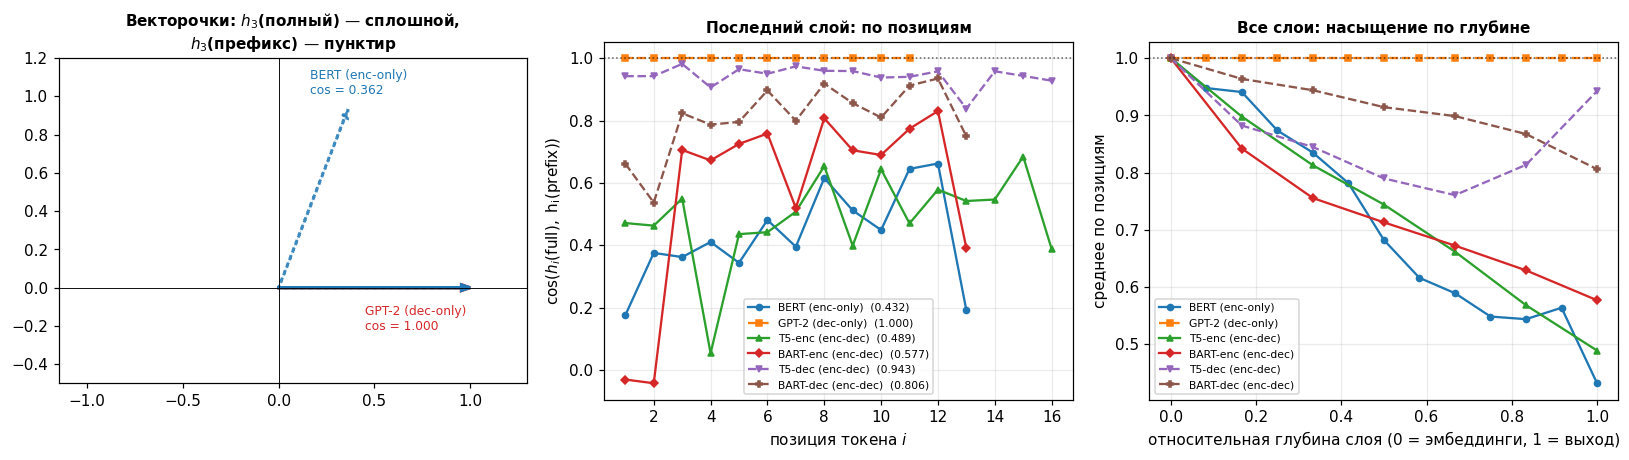

Тип                     последний слой   min по позициям   мин. по слоям
BERT (enc-only)                 0.4320            0.1755          0.4320
GPT-2 (dec-only)                1.0000            1.0000          1.0000
T5-enc (enc-dec)                0.4892            0.0534          0.4892
BART-enc (enc-dec)              0.5771           -0.0428          0.5771
T5-dec (enc-dec)                0.9426            0.8381          0.7607
BART-dec (enc-dec)              0.8061            0.5368          0.8061


In [7]:
# ── Насыщение контекстом: cos(h_i(весь текст), h_i(префикс до i)) ────
def context_saturation(model, tok, sentence):
    """sat[L, i] — косинус на слое L для позиции i. L = 0 это эмбеддинги."""
    ids = tok(sentence, return_tensors="pt")["input_ids"]
    n = ids.shape[1]
    with torch.no_grad():
        full = model(input_ids=ids, output_hidden_states=True).hidden_states

    sat = np.zeros((len(full), n - 2))
    for i in range(1, n - 1):
        with torch.no_grad():
            prefix = model(input_ids=ids[:, : i + 1], output_hidden_states=True).hidden_states
        for L in range(len(full)):
            sat[L, i - 1] = torch.nn.functional.cosine_similarity(
                full[L][0, i], prefix[L][0, i], dim=0
            ).item()
    return sat


SAT = {label: context_saturation(MODEL[label], TOK[label], CAUSAL_TEST_SENTENCE)
       for label in ALL_LABELS}


def two_vectors_2d(model, tok, sentence, i):
    """Настоящие h_i(full) и h_i(prefix) в плоскости, которую они задают.

    Считаем в float64: у GPT-2 нормы под 300, и в float32 разность двух почти
    одинаковых векторов — это чистый шум округления, из которого «плоскость»
    не построишь.
    """
    ids = tok(sentence, return_tensors="pt")["input_ids"]
    with torch.no_grad():
        u = model(input_ids=ids).last_hidden_state[0, i]
        v = model(input_ids=ids[:, : i + 1]).last_hidden_state[0, i]
    u = u.numpy().astype(np.float64)
    v = v.numpy().astype(np.float64)

    e1 = u / np.linalg.norm(u)
    w = v - (v @ e1) * e1
    if np.linalg.norm(w) < 1e-5 * np.linalg.norm(v):      # векторы совпали
        return np.array([1.0, 0.0]), np.array([1.0, 0.0])
    e2 = w / np.linalg.norm(w)
    return np.array([1.0, 0.0]), np.array([v @ e1, v @ e2]) / np.linalg.norm(v)


fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

# (a) векторочки: те же два состояния, но глазами
I_SHOW = 3
for label, color in zip(["GPT-2 (dec-only)", "BERT (enc-only)"], ["tab:red", "tab:blue"]):
    a, b = two_vectors_2d(MODEL[label], TOK[label], CAUSAL_TEST_SENTENCE, I_SHOW)
    axes[0].arrow(0, 0, *a, color=color, lw=2, head_width=0.03, length_includes_head=True)
    axes[0].arrow(0, 0, *b, color=color, lw=2, ls=":", head_width=0.03,
                  length_includes_head=True, alpha=0.85)
    off = 0.08 if b[1] > 0.05 else -0.22   # совпавшие стрелки подписываем снизу
    axes[0].annotate(f"{label}\ncos = {a @ b:.3f}", xy=b, xytext=(b[0] * 0.45, b[1] + off),
                     fontsize=8, color=color)
axes[0].set_xlim(-1.15, 1.3); axes[0].set_ylim(-0.5, 1.2)
axes[0].axhline(0, color="k", lw=0.6); axes[0].axvline(0, color="k", lw=0.6)
axes[0].set_aspect("equal")
axes[0].set_title(f"Векторочки: $h_{{{I_SHOW}}}$(полный) — сплошной,\n"
                  f"$h_{{{I_SHOW}}}$(префикс) — пунктир", fontsize=10, fontweight="bold")

# (b) по позициям, последний слой 
for label, marker in zip(ALL_LABELS, MARKERS):
    s = SAT[label][-1]
    axes[1].plot(range(1, len(s) + 1), s, marker + style(label), ms=4,
                 label=f"{label}  ({s.mean():.3f})")
axes[1].axhline(1.0, color="k", ls=":", lw=1, alpha=0.6)
axes[1].set_xlabel("позиция токена $i$")
axes[1].set_ylabel(r"$\cos(h_i(\rm full),\ h_i(\rm prefix))$")
axes[1].set_title("Последний слой: по позициям", fontsize=10, fontweight="bold")
axes[1].legend(fontsize=7)
axes[1].grid(alpha=0.25)

# (c) по глубине: среднее по позициям на каждом слое, ось — относительная глубина
for label, marker in zip(ALL_LABELS, MARKERS):
    m = SAT[label].mean(axis=1)
    depth = np.arange(len(m)) / (len(m) - 1)
    axes[2].plot(depth, m, marker + style(label), ms=4, label=label)
axes[2].axhline(1.0, color="k", ls=":", lw=1, alpha=0.6)
axes[2].set_xlabel("относительная глубина слоя (0 = эмбеддинги, 1 = выход)")
axes[2].set_ylabel("среднее по позициям")
axes[2].set_title("Все слои: насыщение по глубине", fontsize=10, fontweight="bold")
axes[2].legend(fontsize=7)
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(f"{'Тип':22s} {'последний слой':>15s} {'min по позициям':>17s} {'мин. по слоям':>15s}")
for label in ALL_LABELS:
    s = SAT[label]
    print(f"{label:22s} {s[-1].mean():15.4f} {s[-1].min():17.4f} {s.mean(axis=1).min():15.4f}")

### **Что мы видим**

- **GPT-2 даёт 1 на всех позициях.** Это и есть смысл фразы «в каузальной модели ранние токены недоконтекстуализированы». Каждый токен получает своё направление и никак не меняет его при дальнейшем добавлении контекста.  

- **Все три двунаправленные модели дают заметно меньше единицы**: 0.432 у BERT, 0.489 у энкодера T5, 0.577 у энкодера BART, а на отдельных позициях значения проваливаются к нулю и даже уходят в минус. То есть правый контекст переписывает представление токена почти полностью.

- **А декодеры T5 и BART дают меньше единицы — и это не противоречие.** Обрезая текст, мы обрезаем вход **энкодера**, а его декодер читает через cross-attention без всякой маски. Каузальна у него только собственная история (мы это проверили в части 1), поэтому в этом тесте он ведёт себя как двунаправленная модель. Ровно то же самое произойдёт с любым RAG-подобным пайплайном: «декодерная модель» и «модель, у которой представление не зависит от правого контекста» — не синонимы.

- **По глубине картина одинаковая у всех:** на нулевом слое (эмбеддинги) насыщение равно единице у всех типов просто потому, что эмбеддинг токена контекста ещё не видел, а дальше двунаправленные типы уезжают вниз с первого же слоя. То есть «недоконтекстуализированность» — свойство не выхода, а всей глубины.

Практическое следствие:

> Среднее `.mean(dim=1)` по токенам декодерной модели (у нас — GPT-2), усредняет векторы, часть которых физически не содержит информации о тексте. Первый токен видел одно слово. Второй — два. Это усреднение **систематически** смещено в сторону начала текста.
    Для encoder моделей BERT та же операция осмысленна: там все позиции видели всё.

### **2.2 Attention sink: первый токен как сливной клапан**

Второй фактор информативности — не «что токен видел», а «сколько внимания он получил».

При анализе attention существует эффект: первая позиция собирает непропорционально большую долю внимания ([Xiao et al., 2023](https://arxiv.org/abs/2309.17453), StreamingLLM).  Такой эффект называется  Attention sink. Он возникает потому, что softmax по строке обязан просуммироваться в единицу — голова **не может** «не смотреть никуда». Когда голове на данном шаге нечего искать, ей нужно куда-то слить массу внимания, и самая удобная свалка — позиция, которая видна отовсюду и не несёт содержания. Отсюда название — **attention sink**.

> **Формально.** Пусть $a^{(\ell,h)}_{ij}$ — вес внимания головы $h$ слоя $\ell$ из позиции-запроса $i$ в позицию-ключ $j$. Мерой стока назовём
>
> $$\text{sink}(\ell) = \operatorname*{median}_{h,\, i}\ a^{(\ell,h)}_{i0}$$
>
> — медиану доли внимания, уходящей в позицию 0, по всем головам и всем запросам слоя. Медиана, а не среднее, и это важно: доли по головам распределены крайне несимметрично, одна голова-сливщик с долей 0.95 утаскивает среднее вверх, и получается впечатление, будто течёт весь слой. Медиана отвечает на честный вопрос — «как ведёт себя **типичная** голова».
>
> **Toy-пример: откуда сток берётся арифметически.** Строка softmax нормирована при любых логитах: $\sum_j a_{ij} = 1$. Пусть у запроса $q_i$ нет ни одного содержательного совпадения — все $\langle q_i, k_j \rangle \approx 0$, — но у позиции 0 логит равен $s_0$ (ключ там всегда один и тот же, модели ничего не стоит его выучить). Тогда
>
> $$a_{i0} = \frac{e^{s_0}}{e^{s_0} + (n - 1)}$$
>
> При $n = 15$ достаточно $s_0 \approx 4$, чтобы в позицию 0 ушло больше 80% внимания. Никакой семантики: голове просто некуда деть массу, а нулевая позиция — единственный всегда доступный адрес. Эту кривую мы нарисуем рядом с реальными долями.

Обычно этот эффект описывают как свойство декодерных моделей. Проверим, так ли это и как в энкодерах — посчитаем долю массы внимания, уходящую на позицию 0, усреднив по головам и запросам, по слоям.

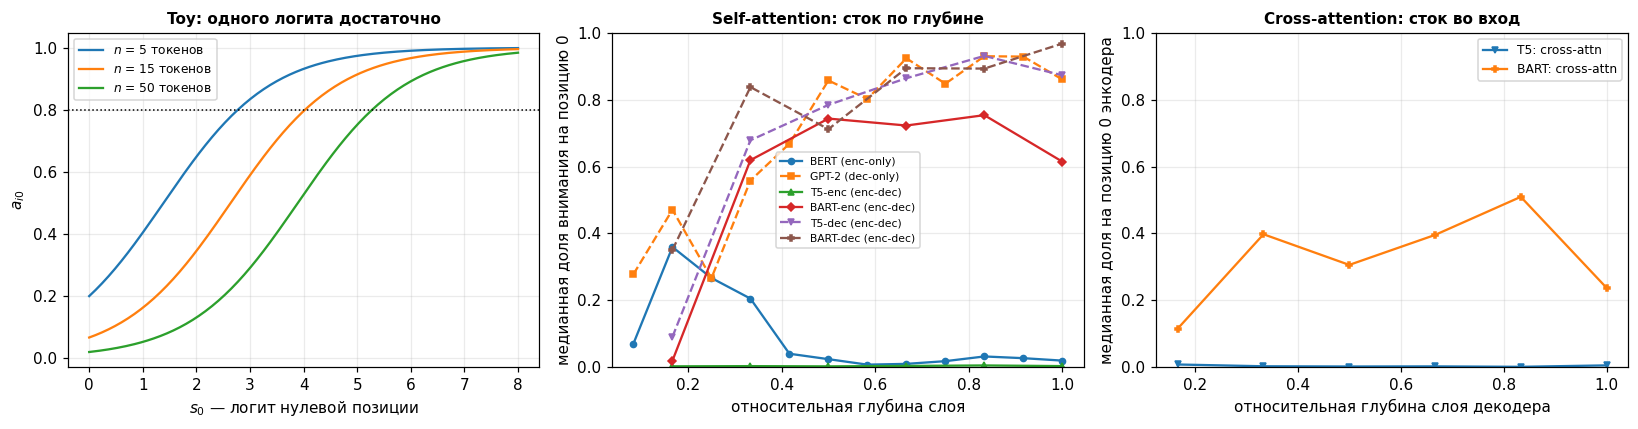

тип                        первый токен  медиана стока по слоям
BERT (enc-only)                   [CLS]  0.07 0.36 0.27 0.21 0.04 0.02 0.01 0.01 0.02 0.03 0.03 0.02
GPT-2 (dec-only)          <|endoftext|>  0.28 0.47 0.27 0.56 0.67 0.86 0.80 0.92 0.85 0.93 0.93 0.86
T5-enc (enc-dec)                   ▁You  0.00 0.00 0.00 0.00 0.01 0.00
BART-enc (enc-dec)                  <s>  0.02 0.62 0.74 0.72 0.75 0.61
T5-dec (enc-dec)                  <pad>  0.09 0.68 0.78 0.86 0.93 0.87
BART-dec (enc-dec)                 </s>  0.35 0.84 0.71 0.89 0.89 0.97
T5-dec (enc-dec) / cross                —  0.01 0.00 0.00 0.00 0.00 0.01
BART-dec (enc-dec) / cross                —  0.12 0.40 0.31 0.40 0.51 0.24


In [8]:
# ── Attention sink: доля массы внимания, уходящей на позицию 0 ───────
# Важно: в transformers 5.x по умолчанию стоит SDPA, и при ней
# output_attentions=True молча возвращает []. Поэтому выше всё грузится с eager.
def _with_bos(tok, sentence, add_bos):
    enc = tok(sentence, return_tensors="pt")
    if add_bos:  # у GPT-2 нет BOS по умолчанию — подставляем eos вместо него
        enc["input_ids"] = torch.cat(
            [torch.tensor([[tok.eos_token_id]]), enc["input_ids"]], dim=1
        )
        enc["attention_mask"] = torch.ones_like(enc["input_ids"])
    return enc


def attention_sink(model, tok, sentence, add_bos=False, which="self"):
    """Медианная доля внимания на позицию 0, по слоям.

    Медиана по головам и запросам: распределение по головам очень
    несимметрично, и одна голова-сливщик утащила бы среднее за весь слой.
    """
    enc = _with_bos(tok, sentence, add_bos)
    with torch.no_grad():
        out = model(**enc, output_attentions=True)

    atts = out.attentions if which == "self" else out.cross_attentions
    assert atts, "пустой attentions — модель загружена не с eager"
    # a: [batch, heads, запросы, ключи] -> медиана по головам и запросам, столбец 0
    return [float(a[0][:, :, 0].median()) for a in atts]


SINK = {
    label: attention_sink(
        MODEL[label], TOK[label], CAUSAL_TEST_SENTENCE, add_bos=("GPT-2" in label)
    )
    for label in ALL_LABELS
}
CROSS_SINK = {
    label: attention_sink(MODEL[label], TOK[label], CAUSAL_TEST_SENTENCE, which="cross")
    for label in S2S_IDS
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.0))

# (a) toy: сколько массы уходит в позицию 0 при одном выученном логите
s0 = np.linspace(0, 8, 200)
for n in (5, 15, 50):
    axes[0].plot(s0, np.exp(s0) / (np.exp(s0) + (n - 1)), label=f"$n$ = {n} токенов")
axes[0].axhline(0.8, color="k", ls=":", lw=1)
axes[0].set_xlabel("$s_0$ — логит нулевой позиции")
axes[0].set_ylabel("$a_{i0}$")
axes[0].set_title("Toy: одного логита достаточно", fontsize=10, fontweight="bold")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.25)

# (b) сток по относительной глубине
for label, marker in zip(ALL_LABELS, MARKERS):
    v = SINK[label]
    depth = (np.arange(len(v)) + 1) / len(v)
    axes[1].plot(depth, v, marker + style(label), ms=4, label=label)
axes[1].set_xlabel("относительная глубина слоя")
axes[1].set_ylabel("медианная доля внимания на позицию 0")
axes[1].set_title("Self-attention: сток по глубине", fontsize=10, fontweight="bold")
axes[1].legend(fontsize=7)
axes[1].grid(alpha=0.25)
axes[1].set_ylim(0, 1)

# (c) cross-attention: сток в нулевую позицию энкодера
for label, marker in zip(S2S_IDS, MARKERS[4:]):
    v = CROSS_SINK[label]
    depth = (np.arange(len(v)) + 1) / len(v)
    axes[2].plot(depth, v, marker + "-", ms=4, label=label.split(" ")[0].replace("-dec", "") + ": cross-attn")
axes[2].set_xlabel("относительная глубина слоя декодера")
axes[2].set_ylabel("медианная доля на позицию 0 энкодера")
axes[2].set_title("Cross-attention: сток во вход", fontsize=10, fontweight="bold")
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.25)
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print(f"{'тип':22s} {'первый токен':>16s}  медиана стока по слоям")
for label in ALL_LABELS:
    first_tok = TOK[label].convert_ids_to_tokens(
        _with_bos(TOK[label], CAUSAL_TEST_SENTENCE, "GPT-2" in label)["input_ids"][0][:1]
    )[0]
    if label in S2S_IDS:
        first_tok = TOK[label].convert_ids_to_tokens(
            [S2S[label].config.decoder_start_token_id]
        )[0]
    print(f"{label:22s} {first_tok:>16s}  " + " ".join(f"{x:.2f}" for x in SINK[label]))
for label in S2S_IDS:
    print(f"{label + ' / cross':22s} {'—':>16s}  " + " ".join(f"{x:.2f}" for x in CROSS_SINK[label]))

### **Что мы видим**

**Медианно для GPT-2: к глубоким слоям до 93% всего внимания уходит в первый токен.** Модель почти перестаёт «смотреть на текст» и сливает внимание в сток.

Энкодер BART — модель **двунаправленная** — показывает сток почти такой же силы: 0.61–0.75 начиная со второго слоя. Отсюда мы видим, что следствие слития зависит не только от архитектуры, а зависит ещё и от наличия служебного токена. А именно, для наших моделей справедливо следующее:

| тип | маска | первый токен | сток (медиана по головам и запросам) |
|---|---|---|---|
| GPT-2 | каузальная | BOS (мы добавили) | **до 0.93** |
| энкодер BART | двунаправленная | `<s>`, всегда | **до 0.75** |
| BERT | двунаправленная | `[CLS]`, всегда | 0.36 в начале, затем 0.01–0.03 |
| энкодер T5 | двунаправленная | **отсутствует** | 0.00–0.01, стока нет |
| декодер T5 | каузальная | `<pad>` как `decoder_start` | **до 0.93** |
| декодер BART | каузальная | `</s>` как `decoder_start` | **до 0.97** |

- У GPT-2 и BART он есть и работает свалкой на всей глубине. У BERT `[CLS]` есть, но сток держится только в первых слоях. У T5 начального служебного токена нет — и стока нет.

-  Энкодер T5 и декодер T5 — это одна модель: один претрейн, один токенизатор, одна схема нормализации, одинаковое число слоёв и голов. Разница между ними — маска и наличие стартового токена. У энкодера начального служебного токена нет, и стока нет: 0.00–0.01 на всех шести слоях. Декодер той же самой T5 начинает последовательность с `<pad>` — и сток доходит до 0.93. Эффект снова включается там, где появляется постоянная пустая позиция.

- Cross-attention не маскирован ни у T5, ни у BART — маска здесь не участвует. И тем не менее: у BART в нулевую позицию энкодера утекает до 0.51, а у T5 — 0.00–0.01. Разница между ними ровно та же, что между их энкодерами, и объясняется тем же: у BART на позиции 0 стоит `<s>`, у T5 — обычное слово.

> Числа выше посчитаны на одном предложении, но они устойчивые: на 12 случайных предложениях из корпуса медианный максимум стока по слоям равен 0.93 у GPT-2 (разброс 0.86–0.96), 0.96 у декодера BART, 0.90 у декодера T5, 0.75 у энкодера BART, 0.35 у BERT и 0.01 у энкодера T5 — порядок типов не меняется.

> Отсюда: механизм такой: голове нужно место, куда слить лишнюю массу внимания, и лучший кандидат — позиция, которая **всегда присутствует, видна отовсюду и не несёт содержания**. А значит, наш **служебный первый токен — часть механизма внимания, а не носитель смысла.** Включать его в mean-pooling не очень корректно — там мы подмешиваем в «эмбеддинг текста» вектор со служебной ролью и, как мы ниже увидим, аномальной величиной. Касается это и GPT-2, и BART, и BERT, и обоих декодеров — то есть всех, у кого такой токен есть.

### **2.3 Нормы: два порядка разницы**

Attention sink имеет геометрического близнеца — **аномально большие нормы** на служебных позициях (их называют massive activations, [Sun et al., 2024](https://arxiv.org/abs/2402.17762)).

Посмотрим на эффект в действии. 

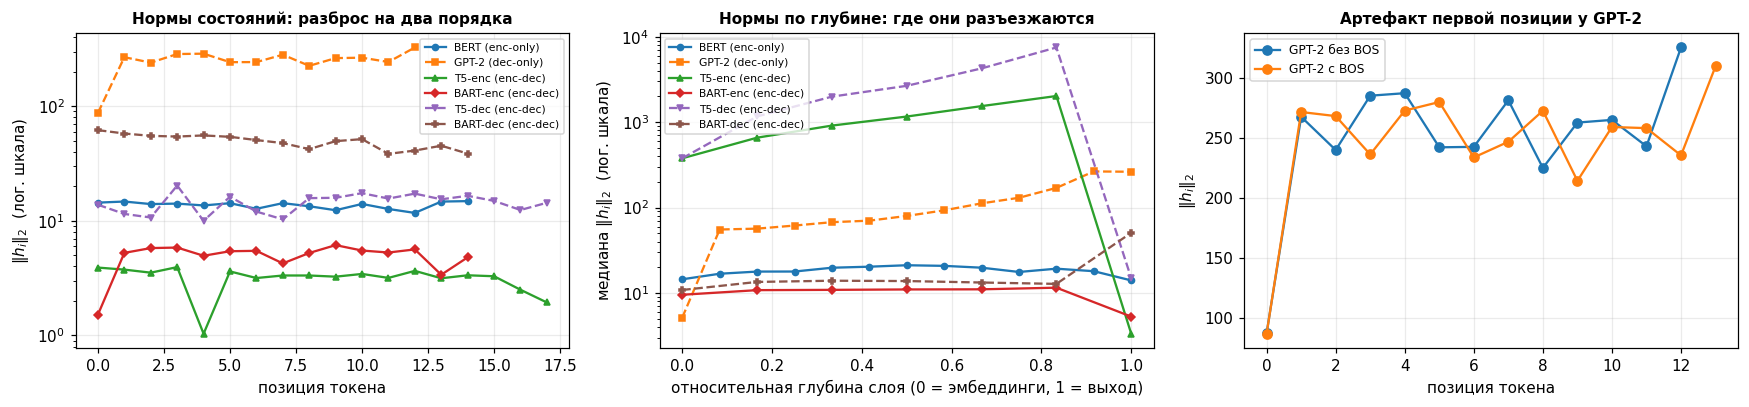

BERT (enc-only)        медиана нормы =   14.03   max =   14.85
GPT-2 (dec-only)       медиана нормы =  262.88   max =  325.44
T5-enc (enc-dec)       медиана нормы =    3.33   max =    3.94
BART-enc (enc-dec)     медиана нормы =    5.29   max =    6.14
T5-dec (enc-dec)       медиана нормы =   14.92   max =   20.30
BART-dec (enc-dec)     медиана нормы =   50.65   max =   61.83

Одна модель, два типа — во сколько раз декодер «крупнее» своего энкодера:
  T5-dec (enc-dec)        14.92 /  3.33 = 4.5x
  BART-dec (enc-dec)      50.65 /  5.29 = 9.6x

тип                        слой 0   макс по слоям      выход
BERT (enc-only)              14.5            21.1       14.0
GPT-2 (dec-only)              5.2           265.1      262.9
T5-enc (enc-dec)            378.0          2026.0        3.3
BART-enc (enc-dec)            9.5            11.5        5.3
T5-dec (enc-dec)            378.0          7500.7       14.9
BART-dec (enc-dec)           10.8            50.6       50.6


In [9]:
# ── Нормы: по позициям, по глубине и артефакт BOS ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))

# (a) нормы на выходе у всех шести типов
for label, marker in zip(ALL_LABELS, MARKERS):
    enc = TOK[label](CAUSAL_TEST_SENTENCE, return_tensors="pt")
    with torch.no_grad():
        H = MODEL[label](**enc).last_hidden_state[0]
    axes[0].plot(H.norm(dim=-1).numpy(), marker + style(label), ms=4, label=label)
axes[0].set_yscale("log")
axes[0].set_xlabel("позиция токена")
axes[0].set_ylabel(r"$\|h_i\|_2$  (лог. шкала)")
axes[0].set_title("Нормы состояний: разброс на два порядка", fontsize=10, fontweight="bold")
axes[0].legend(fontsize=7)
axes[0].grid(alpha=0.25)

# (b) те же нормы по глубине: медиана по позициям каждого слоя
NORM_BY_LAYER = {}
for label, marker in zip(ALL_LABELS, MARKERS):
    enc = TOK[label](CAUSAL_TEST_SENTENCE, return_tensors="pt")
    with torch.no_grad():
        hs = MODEL[label](**enc, output_hidden_states=True).hidden_states
    med = [float(h[0].norm(dim=-1).median()) for h in hs]
    NORM_BY_LAYER[label] = med
    axes[1].plot(np.arange(len(med)) / (len(med) - 1), med,
                 marker + style(label), ms=4, label=label)
axes[1].set_yscale("log")
axes[1].set_xlabel("относительная глубина слоя (0 = эмбеддинги, 1 = выход)")
axes[1].set_ylabel(r"медиана $\|h_i\|_2$  (лог. шкала)")
axes[1].set_title("Нормы по глубине: где они разъезжаются", fontsize=10, fontweight="bold")
axes[1].legend(fontsize=7)
axes[1].grid(alpha=0.25)

# (c) артефакт первой позиции у GPT-2
tok_g, mdl_g = TOK["GPT-2 (dec-only)"], MODEL["GPT-2 (dec-only)"]
for name, prefix in [("без BOS", []), ("с BOS", [tok_g.eos_token_id])]:
    ids = torch.tensor([prefix + tok_g.encode(CAUSAL_TEST_SENTENCE)])
    with torch.no_grad():
        H = mdl_g(input_ids=ids).last_hidden_state[0]
    axes[2].plot(H.norm(dim=-1).numpy(), "o-", label=f"GPT-2 {name}")
axes[2].set_xlabel("позиция токена")
axes[2].set_ylabel(r"$\|h_i\|_2$")
axes[2].set_title("Артефакт первой позиции у GPT-2", fontsize=10, fontweight="bold")
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()

MED_NORM = {}
for label in ALL_LABELS:
    enc = TOK[label](CAUSAL_TEST_SENTENCE, return_tensors="pt")
    with torch.no_grad():
        H = MODEL[label](**enc).last_hidden_state[0]
    nr = H.norm(dim=-1)
    MED_NORM[label] = float(nr.median())
    print(f"{label:22s} медиана нормы = {nr.median():7.2f}   max = {nr.max():7.2f}")

print("\nОдна модель, два типа — во сколько раз декодер «крупнее» своего энкодера:")
for dec, enc_label in (("T5-dec (enc-dec)", "T5-enc (enc-dec)"),
                       ("BART-dec (enc-dec)", "BART-enc (enc-dec)")):
    print(f"  {dec:22s} {MED_NORM[dec]:6.2f} / {MED_NORM[enc_label]:5.2f} = "
          f"{MED_NORM[dec] / MED_NORM[enc_label]:.1f}x")

print(f"\n{'тип':22s} {'слой 0':>10s} {'макс по слоям':>15s} {'выход':>10s}")
for label in ALL_LABELS:
    med = NORM_BY_LAYER[label]
    print(f"{label:22s} {med[0]:10.1f} {max(med):15.1f} {med[-1]:10.1f}")


### **Что мы видим**

Медианные нормы: 3.3 у энкодера T5, 5.3 у энкодера BART, 14.0 у BERT и **263** у GPT-2. **Разброс на два порядка.** Плюс два декодера: 14.9 у T5 и 50.7 у BART.

Причина просто в схеме нормализации: BERT использует post-LayerNorm, GPT-2 — pre-LayerNorm с финальным `ln_f`, T5 — RMSNorm без обучаемого сдвига, BART — обычный LayerNorm. Это архитектурная деталь, которая должна, в идеале, учитываться при анализе везде, где вы применяете нормы. 

**И вот тут видно, что пространство декодера живёт в другом масштабе, чем пространство его собственного энкодера.** У T5 медианные нормы 3.33 против 14.92 — отношение 4.5. У BART 5.29 против 50.65 — отношение 9.6. Один forward pass, одна модель, одни и те же веса — и разница в разы, причём у обеих архитектур.

Это уже достаточная причина никогда не складывать и не косинусить состояния энкодера и декодера. А то, что эффект воспроизвёлся на двух независимо устроенных encoder-decoder, переводит его из разряда «особенность T5» в разряд свойства класса архитектур.

> Мне на практике помогает правило: **любая метрика, чувствительная к масштабу, между архитектурами требует нормировки.** И кроме того, любая метрика требует baseline. 

Помимо статистик с частных примеров, мы можем анализировать и более общие вещи. Давайте посмотрим на структуры/облака точек, которые может триггерить архитектура. 

# **Часть 3. Геометрия**

Облака точек можно характеризовать разными способами. Я субъективно выбрала три красивые. Три — чтобы туториал не был очень широким, а то мы и так расползлись. 

Я допускаю, что математика вам не знакома или знакома не вся. Поэтому сейчас зафиксируем интуицию и потом — формальные определения. Итак, рассмотрим:

- **Анизотропию** в общем смысле — это зависимость математических свойств объекта, функции, пространства или модели от направления. Мы будем оценивать изотропность пространства — то есть наоборот — одинаковость всех направлений в модели. Сложного слова не пугайтесь — с нами тут просто будет попарный косинус. 
- **Спектр и Participation ratio** — характеристики матрицы, которые скажут, сколько в ней наиболее эффективных направлений. 
- **CKA** — метрика, позволяющая проанализировать похожесть моделей между собой (в смысле организации пространств).  

Если стало сложно, то сейчас по секциям всё уложим. 

In [10]:
# ── Собираем облака токенов ──────────────────────────────────────────
N_TEXTS = 300
MAX_LEN = 48

ag = load_dataset("fancyzhx/ag_news", split="train").shuffle(seed=SEED)
AG_TEXTS = [t[:180] for t in ag.select(range(N_TEXTS))["text"]]


def collect_token_cloud(model, tok, texts, batch_size=16, max_len=MAX_LEN):
    """Все токенные состояния последнего слоя + из какого предложения токен.

    Padding-позиции выбрасываем: они не несут информации и загрязнили бы
    любую геометрическую метрику ниже.
    """
    vecs, sent_ids = [], []
    for start in range(0, len(texts), batch_size):
        batch = texts[start : start + batch_size]
        enc = tok(batch, return_tensors="pt", padding=True, truncation=True, max_length=max_len)
        with torch.no_grad():
            H = model(**enc).last_hidden_state
        mask = enc["attention_mask"].bool()
        for b in range(H.shape[0]):
            n_real = int(mask[b].sum())
            vecs.append(H[b, :n_real])
            sent_ids.extend([start + b] * n_real)
    return torch.cat(vecs).float().numpy(), np.array(sent_ids)


# Декодерные части идут через ту же самую функцию: обёртка прячет то,
# что внутри выполняется полный seq2seq-проход.
CLOUD = {}
for label in ALL_LABELS:
    X, sid = collect_token_cloud(MODEL[label], TOK[label], AG_TEXTS)
    CLOUD[label] = {"X": X, "sid": sid}
    print(f"{label:18s} облако: {X.shape[0]:6d} токенов x {X.shape[1]} измерений")

BERT (enc-only)    облако:  11924 токенов x 768 измерений


GPT-2 (dec-only)   облако:  11676 токенов x 768 измерений


T5-enc (enc-dec)   облако:  13113 токенов x 512 измерений


BART-enc (enc-dec) облако:  12220 токенов x 768 измерений


T5-dec (enc-dec)   облако:  13113 токенов x 512 измерений


BART-dec (enc-dec) облако:  12220 токенов x 768 измерений


Разное количество токенов — следствие словаря модели. Слово коровник, например, может кодироваться в модели номер 1 — одним токеном, а в модели номер два — двумя. 

## **3.1 Анизотропия**

**Теория.** Пространство называется **изотропным**, если случайно взятые из него векторы почти ортогональны. Для гауссова облака в $\mathbb{R}^D$ это так: при большом $D$ косинус двух случайных векторов концентрируется около нуля.

Мера отклонения от изотропии — средний попарный косинус ([Ethayarajh, 2019](https://arxiv.org/abs/1909.00512)):

$$A = \mathbb{E}_{i \ne j,\ s(i) \ne s(j)} \bigl[\cos(h_i, h_j)\bigr]$$

Здесь мы берём токены из **разных** предложений. Внутри одного предложения токены могут быть похожи естественным образом. 

**Как читать:**
- $A \approx 0$ — изотропно, косинус информативен: если два вектора похожи, это что-то значит;
- $A \to 1$ — все векторы смотрят примерно в одну сторону; косинус любой пары ≈ 1, и он **не несёт информации**.

Нашим контролем будет **baseline** — та же самая оценка для гауссова облака той же размерности. Без него мы не сможем сказать, много/мало, случайно или не случайно. А ещё это поможет нам корректнее оценить $D=768$ с $D=512$. 

In [11]:
# ── Анизотропия: средний попарный косинус токенов из разных предложений ──
def anisotropy(X, sent_ids, n_sample=2500, seed=SEED):
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X), min(n_sample, len(X)), replace=False)
    V = X[idx]
    V = V / (np.linalg.norm(V, axis=1, keepdims=True) + 1e-9)
    S = V @ V.T
    s = sent_ids[idx]
    cross_sentence = s[:, None] != s[None, :]
    return float(S[cross_sentence].mean())


print(f"{'тип':22s} {'анизотропия':>12s} {'baseline':>10s}")
ANISO = {}
for label in ALL_LABELS:
    c = CLOUD[label]
    ANISO[label] = anisotropy(c["X"], c["sid"])
    D = c["X"].shape[1]
    G = np.random.default_rng(SEED).standard_normal((2000, D))
    base = anisotropy(G, np.arange(2000))
    print(f"{label:22s} {ANISO[label]:12.3f} {base:10.3f}")

тип                     анизотропия   baseline
BERT (enc-only)               0.227     -0.000
GPT-2 (dec-only)              0.945     -0.000
T5-enc (enc-dec)              0.098     -0.000


BART-enc (enc-dec)            0.184     -0.000
T5-dec (enc-dec)              0.868     -0.000
BART-dec (enc-dec)            0.096     -0.000


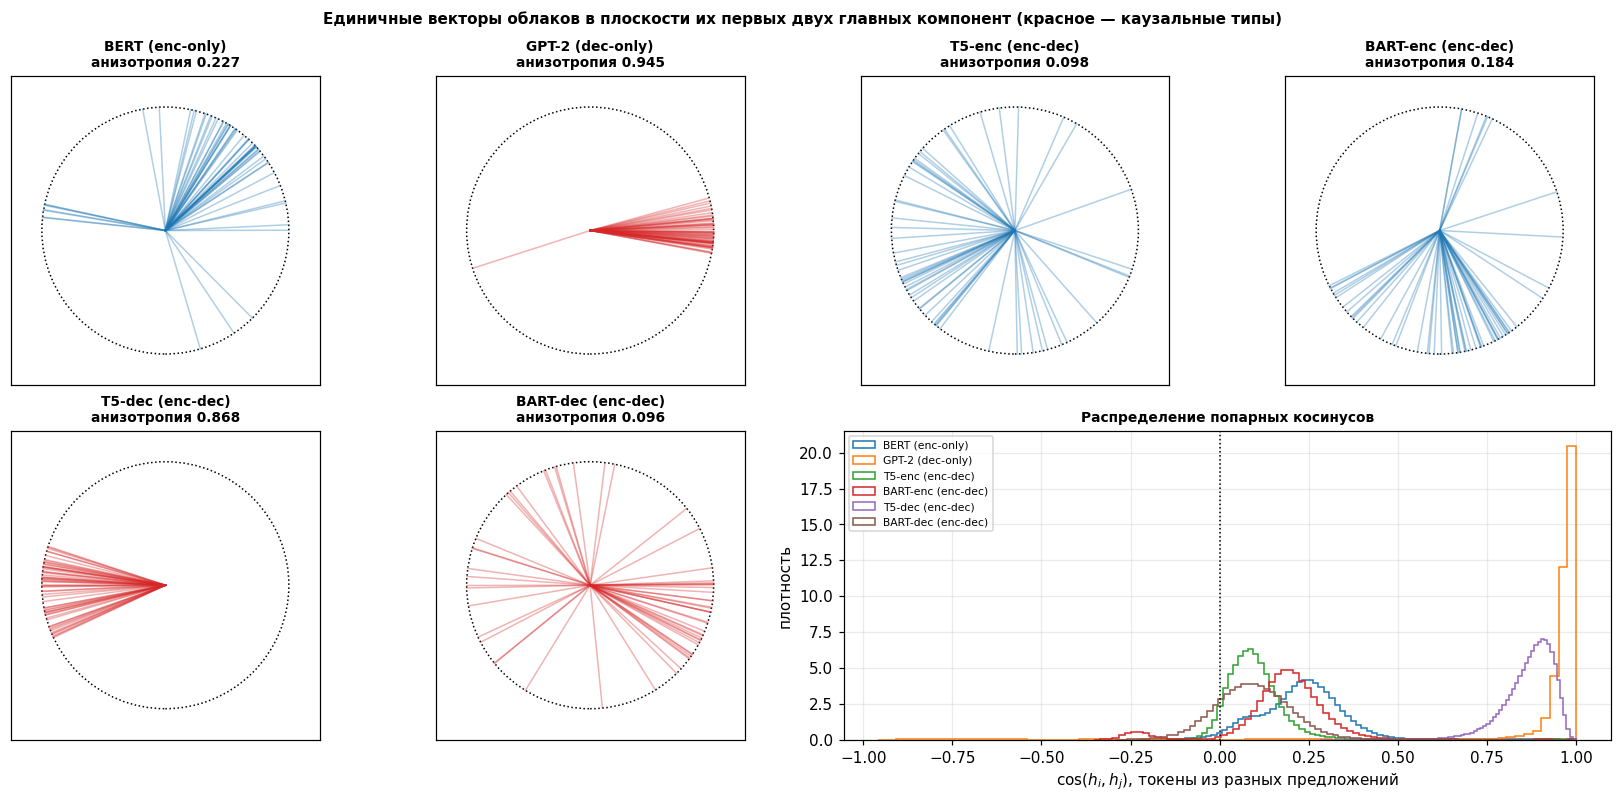

In [12]:
# ── Как это число выглядит: настоящие векторы, настоящие косинусы ────
def unit_sample(label, n=60, seed=SEED):
    """n случайных токенов облака, нормированных, в плоскости первых двух PC."""
    c = CLOUD[label]
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(c["X"]), n, replace=False)
    V = c["X"][idx]
    basis = PCA(n_components=2).fit(c["X"]).components_    # оси только для рисунка
    P = V @ basis.T
    return P / (np.linalg.norm(P, axis=1, keepdims=True) + 1e-9)


fig = plt.figure(figsize=(15, 7.4))
gs = fig.add_gridspec(2, 4)

# (a-f) единичные векторы каждого из шести облаков
for k, label in enumerate(ALL_LABELS):
    ax = fig.add_subplot(gs[k // 4, k % 4])
    color = "tab:red" if label in CAUSAL_STACKS else "tab:blue"
    for p in unit_sample(label):
        ax.plot([0, p[0]], [0, p[1]], color=color, alpha=0.35, lw=1)
    ax.add_patch(plt.Circle((0, 0), 1.0, fill=False, color="k", ls=":", lw=1))
    ax.set_xlim(-1.25, 1.25); ax.set_ylim(-1.25, 1.25)
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"{label}\nанизотропия {ANISO[label]:.3f}", fontsize=9, fontweight="bold")

# (g) распределение попарных косинусов — то же число, но целиком
axh = fig.add_subplot(gs[1, 2:])
rng = np.random.default_rng(SEED)
for label in ALL_LABELS:
    c = CLOUD[label]
    idx = rng.choice(len(c["X"]), 1500, replace=False)
    V = c["X"][idx]
    V = V / (np.linalg.norm(V, axis=1, keepdims=True) + 1e-9)
    S = V @ V.T
    cross = c["sid"][idx][:, None] != c["sid"][idx][None, :]
    axh.hist(S[cross], bins=80, histtype="step", lw=1.5, density=True,
             ls=style(label), label=label)
axh.axvline(0, color="k", ls=":", lw=1)
axh.set_xlabel(r"$\cos(h_i, h_j)$, токены из разных предложений")
axh.set_ylabel("плотность")
axh.set_title("Распределение попарных косинусов", fontsize=9, fontweight="bold")
axh.legend(fontsize=7)
axh.grid(alpha=0.25)

fig.suptitle("Единичные векторы облаков в плоскости их первых двух главных компонент "
             "(красное — каузальные типы)", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()


### **Что мы видим**

Смотрите как это красиво! У GPT-2 лучи собраны в узкий пучок — любая пара векторов почти сонаправлена, — а у BERT и энкодера T5 они расходятся по всей окружности. Справа то же самое в виде распределения: у GPT-2 гистограмма косинусов прижата к единице, у остальных сидит около нуля с длинными хвостами.

- **GPT-2: 0.945.** Следствие — вектора чаще сонаправлены. Отсюда косинусная близость на *выходе GPT-2* **почти не несёт информации**.
- **BERT: 0.227.** Следствие — вектора сонаправлены реже. 
- **Энкодер T5: 0.098** и **энкодер BART: 0.184** — самые «круглые» облака.
- **Гауссов baseline: ~0.00** для обеих размерностей. Именно он говорит нам, что 0.227 у BERT — это *много*, а не «почти ноль».
- **А декодеры разъехались:** 0.868 у декодера T5 — почти как GPT-2, и 0.096 у декодера BART — как самые «круглые» энкодеры. Маска у них одна и та же, каузальная, а анизотропия различается в девять раз.

Уже здесь виден отпечаток типа модели: единственный decoder-only схлопывает пространство сильнее всех, а три двунаправленных энкодера держатся в диапазоне 0.10–0.23 — при том, что objective у них три разных.

> Но декодеры enc-dec сразу же ставят этому объяснению границу: они оба каузальные, а лежат по разные стороны диапазона. Значит, «каузальность» сама по себе анизотропию не объясняет — к этому мы вернёмся в 3.2, когда наберём больше метрик формы.

> И для интуиции — картинка выше: слева единичные векторы облаков в плоскости их же первых двух главных компонент, справа распределение попарных косинусов. Число 0.945 у GPT-2 — это тот самый узкий пучок, а 0.098 у энкодера T5 — лучи по всей окружности.

### **Что можно сделать с высокой анизотропией**


У высокой анизотропии есть две принципиально разные возможные причины.

**Гипотеза А: облако правда сплющено.** Векторы лежат в узком конусе, направления внутри него скоррелированы, геометрия действительно вырождена.

**Гипотеза Б: облако нормальное, но сдвинуто.** Представьте шар единичного радиуса с центром в точке $\mu$, где $\|\mu\| = 10$. Все точки такого шара имеют почти одинаковое направление — просто потому, что шар далеко от начала координат. Косинус между ними будет ≈ 1, хотя **внутренняя** структура облака совершенно нормальная.

Разница между А и Б:
- если А — с пространством действительно беда, и информации в нём мало;
- если Б — вся «беда» лечится одним вычитанием среднего, и информация никуда не девалась.

Различить их можно, сделав простой хинт — посчитать анизотропию **после центрирования** $\tilde h = h - \bar h$. На наших данных, мы получим следующее. 

In [13]:
# ── Откуда берётся конус: сырое облако против центрированного ────────
rows = []
for label in ALL_LABELS:
    c = CLOUD[label]
    X = c["X"]
    Xc = X - X.mean(0)

    rows.append([
        label,
        anisotropy(X, c["sid"]),
        anisotropy(Xc, c["sid"]),
    ])

print(
    pd.DataFrame(
        rows, columns=["модель", "сырая", "после центрирования"]
    ).round(3).to_string(index=False)
)

            модель  сырая  после центрирования
   BERT (enc-only)  0.227               -0.000
  GPT-2 (dec-only)  0.945                0.007
  T5-enc (enc-dec)  0.098                0.000
BART-enc (enc-dec)  0.184               -0.000
  T5-dec (enc-dec)  0.868                0.007
BART-dec (enc-dec)  0.096               -0.000


#### **Что мы видим**

**Анизотропия схлопывается до нуля от одного вычитания среднего — у всех шести типов.** У GPT-2: 0.945 → 0.007. У BERT: 0.227 → −0.000. У энкодера BART: 0.184 → −0.000. И у самого «конусного» из декодеров, T5: 0.868 → 0.007.

Отсюда у нас верна **гипотеза Б**. Пресловутый «конус представлений» — это не вырожденная геометрия, а **смещение облака от начала координат**. Информация внутри облака была на месте всё это время; просто косинус, который меряет углы **из начала координат**, смотрел не туда.

И наше следствие для работы: 
> **Центрируем перед косинусом.** Всегда. Причём среднее надо считать по тому же распределению текстов, на котором работаем. Без этого измеряется  не похожесть текстов, а положение общего центра масс — одинаковое для всех пар.

И тут также видно почему. Например,  `[CLS]`-эмбеддинги «без нормализации плохо работают», а после центрирования считаются нормально. 

## **3.2 Спектр: сколько измерений модель использует**

Теперь зайдём с другой стороны. У облака есть ковариационная матрица, у неё — собственные значения $\lambda_1 \ge \lambda_2 \ge \dots \ge \lambda_D$. Их профиль говорит, по скольким направлениям размазана дисперсия.

По ним мы можем посчитать две (вообще говоря, не две, но две наиболее популярные) статистики. Обе  устроены так, чтобы не зависеть от общего масштаба:

**Participation ratio** — «эффективное число активных направлений»:

$$\text{PR} = \frac{\left(\sum_d \lambda_d\right)^2}{\sum_d \lambda_d^2}$$

Если вся дисперсия в одном направлении, $\text{PR} = 1$. Если она поровну размазана по $k$ направлениям, $\text{PR} = k$.

**Effective rank** — то же самое по смыслу, но через энтропию спектра ([Roy & Vetterli, 2007](https://ieeexplore.ieee.org/document/7098875)):

$$\text{erank} = \exp\left(-\sum_d p_d \log p_d\right), \qquad p_d = \frac{\lambda_d}{\sum_k \lambda_k}$$

Обе метрики зависят от $D$, поэтому снова считаем гауссов baseline: для изотропного облака в $\mathbb{R}^D$ обе величины должны быть порядка $D$.

In [14]:
# ── Спектр: participation ratio и effective rank ─────────────────────
def spectrum_stats(X):
    Xc = X - X.mean(0)
    sv = np.linalg.svd(Xc, compute_uv=False)
    ev = sv ** 2 / (len(Xc) - 1)          # собственные значения ковариации
    p = ev / ev.sum()
    pr = ev.sum() ** 2 / (ev ** 2).sum()  # participation ratio (эффективное число направлений)
    erank = float(np.exp(-(p * np.log(p + 1e-12)).sum()))
    return {"PR": pr, "erank": erank, "p": p, "D": X.shape[1]}


SPEC = {}
rows = []
for label in ALL_LABELS:
    s = spectrum_stats(CLOUD[label]["X"])
    SPEC[label] = s
    rows.append([label, s["D"], s["PR"], s["erank"], s["p"][0], s["p"][:10].sum(),
                 s["PR"] / s["D"]])

# гауссов контроль считаем один раз и переиспользуем на графике ниже
GAUSS = {D: spectrum_stats(np.random.default_rng(SEED).standard_normal((4000, D)))
         for D in sorted({SPEC[l]["D"] for l in ALL_LABELS})}
for D, s in GAUSS.items():
    rows.append([f"гаусс D={D}", D, s["PR"], s["erank"], s["p"][0], s["p"][:10].sum(),
                 s["PR"] / D])

print(
    pd.DataFrame(
        rows, columns=["модель", "D", "PR", "erank", "var@PC1", "var@10PC", "PR/D"]
    ).round(3).to_string(index=False)
)

            модель   D      PR   erank  var@PC1  var@10PC  PR/D
   BERT (enc-only) 768  86.294 276.577    0.068     0.247 0.112
  GPT-2 (dec-only) 768   1.856   3.640    0.723     0.961 0.002
  T5-enc (enc-dec) 512 174.653 289.630    0.027     0.160 0.341
BART-enc (enc-dec) 768 112.859 307.103    0.051     0.226 0.147
  T5-dec (enc-dec) 512   3.377   9.482    0.515     0.874 0.007
BART-dec (enc-dec) 768  67.769 197.841    0.079     0.276 0.088
       гаусс D=512 512 453.917 480.284    0.004     0.035 0.887
       гаусс D=768 768 644.736 697.919    0.003     0.026 0.839


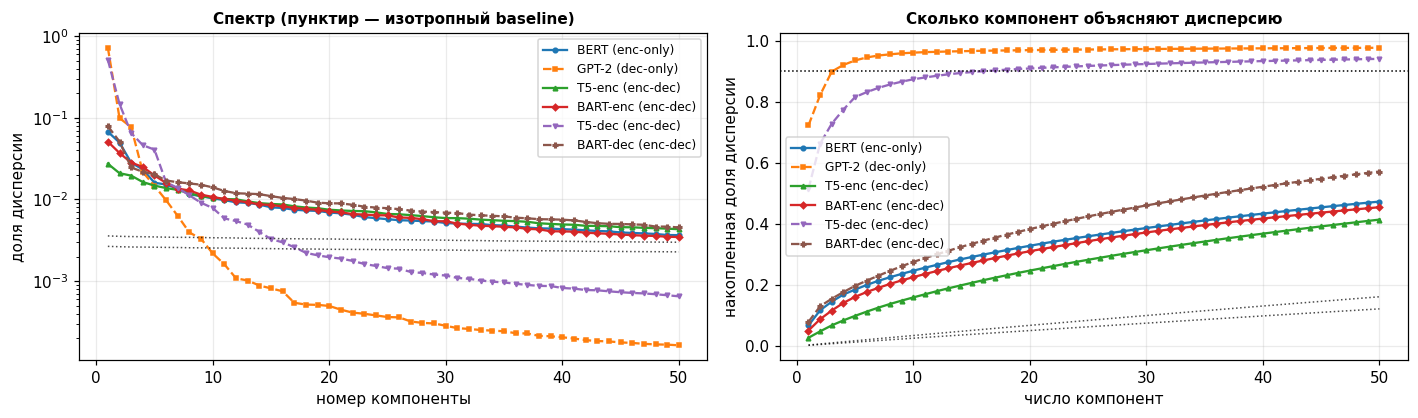

In [15]:
# ── График спектра ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 3.9))

for label, marker in zip(ALL_LABELS, MARKERS):
    p = SPEC[label]["p"]
    axes[0].plot(np.arange(1, 51), p[:50], marker + style(label), ms=3, label=label)
    axes[1].plot(np.arange(1, 51), np.cumsum(p[:50]), marker + style(label), ms=3, label=label)

for D, s in GAUSS.items():
    p = s["p"]
    axes[0].plot(np.arange(1, 51), p[:50], "k:", lw=1, alpha=0.7)
    axes[1].plot(np.arange(1, 51), np.cumsum(p[:50]), "k:", lw=1, alpha=0.7)

axes[0].set_yscale("log")
axes[0].set_xlabel("номер компоненты")
axes[0].set_ylabel("доля дисперсии")
axes[0].set_title("Спектр (пунктир — изотропный baseline)", fontsize=10, fontweight="bold")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.25)

axes[1].set_xlabel("число компонент")
axes[1].set_ylabel("накопленная доля дисперсии")
axes[1].set_title("Сколько компонент объясняют дисперсию", fontsize=10, fontweight="bold")
axes[1].axhline(0.9, color="k", ls=":", lw=1)
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

### **Что мы видим**


- **GPT-2: PR ≈ 1.9 при $D = 768$.** Первая главная компонента объясняет 72% дисперсии, первые десять — 96%. Облако тысяч токенных состояний, живущее формально в 768-мерном пространстве, по дисперсии вообще-то упаковало всё примерно в два направления.
- **BERT: PR ≈ 86**, effective rank ≈ 277, и **энкодер BART: PR ≈ 113** при той же $D = 768$. Моделька на два порядка «объёмнее» GPT-2 при **той же самой** размерности.
- **Энкодер T5: PR ≈ 175** при $D = 512$ — относительно своей размерности самый распределённый.
- **Гауссов baseline: PR ≈ 645** при $D = 768$ и ≈ 454 при $D = 512$.
- **Декодеры снова разъехались:** PR ≈ 3.4 у декодера T5 (PR/D = 0.007, то есть почти GPT-2) и PR ≈ 68 у декодера BART (PR/D = 0.088, то есть почти его собственный энкодер).

Колонка `PR/D` делает сравнение чуть более корректным между разными $D$: 0.002 у GPT-2 против 0.112 у BERT, 0.147 у энкодера BART и 0.341 у энкодера T5.

Разница объясняется маской внимания и objective.

- **Objective решает, во что упирается выход.** У CLM последний слой читается ровно одним линейным отображением — `lm_head`, то есть $W_E^\top h$ с завязанными весами эмбеддингов. Всё, что не помогает разложить $h$ по строкам $W_E$, дисперсии не получает: направление, полезное для предсказания следующего токена, усиливается, остальные ужимаются. Плюс к этому pre-LN архитектура GPT-2 накапливает в residual stream несколько координат-гигантов (те самые massive activations из раздела 2.3), и они забирают почти весь след ковариации. Отсюда $\text{PR} \approx 2$: это не «мало информации», а «вся дисперсия сложена в пару служебных направлений».

У MLM давление обратное: из **каждой** позиции нужно восстановить её собственный токен, то есть каждая позиция обязана нести и идентичность слова, и контекст. Одно направление такое не вместит — дисперсия расползается по десяткам.

У span corruption и denoising выход энкодера вообще не читается линейным классификатором: его читает декодер через cross-attention, на всех позициях и на всех слоях сразу. Такое представление выгоднее держать «широким» — отсюда самые большие PR/D у энкодеров T5 и BART.

- **Маска решает, сколько независимых ролей у позиций.** В двунаправленном типе все позиции равноправны и каждая видит весь текст, поэтому облако токенов — это облако *разных* контекстуализированных смыслов. В каузальном типе позиция $i$ видит только префикс, и соседние позиции отличаются ровно на один токен: состояния идут почти вложенной цепочкой, сильно скоррелированной вдоль текста. Такое облако по построению уже, чем двунаправленное. По крайней мере, так подсказывает интуиция — и вот её-то мы сейчас и проверим.

Отсюда полное следствие: **форму облака задаёт не маска, а то, что читает выход, плюс схема нормализации.** Маска сюда входит только косвенно — через то, что каузальный выход обычно читается одной линейной головой.

Что тогда вообще определяется маской? Не форма, а **структура сходств** — «какие тексты эта модель считает похожими». Ровно её мы и будем мерить в 3.3. Забегая вперёд: там нас тоже ждёт поправка, и тоже от декодеров.

## **3.3 Сравнивать два пространства между собой**

Мы описали каждое облако по отдельности. Перейдем к финальной части — оценим **насколько похожи пространства двух разных моделей?**

Наивный ответ — «посчитаем косинус между эмбеддингами BERT и GPT-2» — не просто плох, он **не определён**. Координаты $h^{\text{BERT}}_5$ и $h^{\text{GPT-2}}_5$ — это разные числа про разные вещи; между базисами двух независимо обученных моделей нет никакого соответствия. А для T5 ещё и размерности не совпадают.

Самый классический вариант корректно померить два пространства **Linear CKA** (Centered Kernel Alignment, [Kornblith et al., 2019](https://arxiv.org/abs/1905.00414)):

$$\text{CKA}(X, Y) = \frac{\|Y^\top X\|_F^2}{\|X^\top X\|_F \cdot \|Y^\top Y\|_F}, \qquad X, Y \text{ центрированы}$$

CKA сравнивает не координаты, а **матрицы попарных сходств объектов**: «одинаково ли эти два пространства считают, какие тексты похожи друг на друга». Отсюда инвариантность к ортогональным поворотам и к изотропному масштабированию и работоспособность при разных $D$. 

In [16]:
# ── Сравнение пространств: linear CKA при разных D ───────────────────
def linear_cka(X, Y):
    """Похожесть двух пространств представлений; работает при разных D."""
    X = X - X.mean(0)
    Y = Y - Y.mean(0)
    return float(
        np.linalg.norm(Y.T @ X, "fro") ** 2
        / (np.linalg.norm(X.T @ X, "fro") * np.linalg.norm(Y.T @ Y, "fro"))
    )


def mean_pool(model, tok, texts, batch_size=16, max_len=MAX_LEN):
    """Представления предложений: mean pooling с учётом маски."""
    out = []
    for start in range(0, len(texts), batch_size):
        enc = tok(texts[start : start + batch_size], return_tensors="pt",
                  padding=True, truncation=True, max_length=max_len)
        with torch.no_grad():
            H = model(**enc).last_hidden_state
        m = enc["attention_mask"].unsqueeze(-1).float()
        out.append((H * m).sum(1) / m.sum(1))
    return torch.cat(out).float().numpy()


# У CKA сильное конечно-выборочное смещение: при n, сравнимом с D, даже два
# случайных облака дают высокое значение. Поэтому здесь выборка текстов больше,
# чем в остальном ноутбуке, и шумовой пол считается для каждой модели отдельно.
CKA_TEXTS = [t[:180] for t in ag.select(range(2000))["text"]]
SENT_REP = {label: mean_pool(MODEL[label], TOK[label], CKA_TEXTS, batch_size=32)
            for label in ALL_LABELS}

labels = list(ALL_LABELS)
cka_mat = np.array([[linear_cka(SENT_REP[a], SENT_REP[b]) for b in labels] for a in labels])
print(f"Linear CKA, n={len(CKA_TEXTS)} текстов, mean pooling:\n")
print(pd.DataFrame(cka_mat, index=labels, columns=labels).round(3).to_string())

rng = np.random.default_rng(SEED)
print("\nШумовой пол — CKA той же модели против гауссова облака:\n")
for l in labels:
    D = SENT_REP[l].shape[1]
    floor = linear_cka(SENT_REP[l], rng.standard_normal((len(CKA_TEXTS), D)))
    print(f"  {l:18s} vs шум: {floor:.3f}")

print("\nЗависимость шумового пола от размера выборки (шум против шума, D=768):")
for n in (300, 600, 2000):
    print(f"  n={n:5d}: {linear_cka(rng.standard_normal((n, 768)), rng.standard_normal((n, 768))):.3f}")

Linear CKA, n=2000 текстов, mean pooling:

                    BERT (enc-only)  GPT-2 (dec-only)  T5-enc (enc-dec)  BART-enc (enc-dec)  T5-dec (enc-dec)  BART-dec (enc-dec)
BERT (enc-only)               1.000             0.125             0.653               0.721             0.146               0.673
GPT-2 (dec-only)              0.125             1.000             0.206               0.228             0.235               0.278
T5-enc (enc-dec)              0.653             0.206             1.000               0.779             0.307               0.711
BART-enc (enc-dec)            0.721             0.228             0.779               1.000             0.270               0.823
T5-dec (enc-dec)              0.146             0.235             0.307               0.270             1.000               0.378
BART-dec (enc-dec)            0.673             0.278             0.711               0.823             0.378               1.000

Шумовой пол — CKA той же модели против гауссов

### **Что мы видим — заглавный результат туториала**

По baseline:

- **У CKA есть сильное конечно-выборочное смещение.** Два **полностью случайных** облака при $n = 300$ дают CKA около 0.72, при $n = 600$ — около 0.56, и даже при $n = 2000$ — всё ещё около 0.28. Причина в том, что при $n$, сравнимом с $D$, у двух случайных облаков неизбежно находится много совпадающих направлений просто по счёту.

> Это ловушка, в которую легко попасть: посчитать CKA на паре сотен примеров, получить 0.6 и написать «пространства похожи». Поэтому мы взяли для этого раздела 2000 текстов и посчитали шумовой пол **для каждой модели отдельно** — CKA той же модели против гауссова облака той же формы.


По результатам моделей:

| пара | CKA | что общего |
|---|---|---|
| энкодер T5 ↔ энкодер BART | **0.779** | двунаправленность |
| BERT ↔ энкодер BART | **0.721** | двунаправленность |
| BERT ↔ энкодер T5 | **0.653** | двунаправленность |
| GPT-2 ↔ энкодер BART | 0.228 | — |
| GPT-2 ↔ энкодер T5 | 0.206 | — |
| GPT-2 ↔ BERT | **0.125** | одинаковые $D$, глубина, число голов |
| декодер BART ↔ энкодер BART | **0.823** | самая похожая пара во всей матрице |
| декодер BART ↔ энкодер T5 | 0.711 | каузальный тип внутри «двунаправленного» кластера |
| декодер BART ↔ BERT | 0.673 | и с BERT тоже |
| декодер T5 ↔ энкодер T5 | 0.307 | а тут собственный энкодер далеко |
| декодер T5 ↔ GPT-2 | 0.235 | и «сосед по маске» тоже далеко |
| декодер T5 ↔ BERT | 0.146 | при шумовом поле 0.022 |

- Три двунаправленных энкодера — плотный кластер 0.65–0.78. У них разные $D$, глубина, objective, токенизатор и корпус претрейна. Общее ровно одно — двунаправленная маска.

- GPT-2 стоит в стороне от каждого из них (0.13–0.23) при шуме  0.02–0.09. Причём самая низкая похожесть во всей матрице — 0.125 у пары BERT/GPT-2, то есть у пары, которая совпадает по $D$, по глубине и по числу голов. Различаются они только маской.

- А декодеры enc-dec вносят вопросы. BART-dec попал внутрь кластера двунаправленных (0.823 со своим энкодером, 0.673 с BERT), а T5-dec лежит сам по себе (0.15–0.38). Маска у них при этом одна и та же, каузальная.

Причин у этого расхождения может быть две:

1. Протокол. Мы сами подали декодеру тот же текст teacher forcing-ом, так что он прочитал его дважды: через cross-attention и как собственную историю. Соблазнительно объявить, что вся похожесть отсюда, — но не совсем. Проверка в ноутбуке: те же CKA, но декодеру подаётся либо фиксированный нейтральный префикс, либо вообще один стартовый токен. В обоих случаях единственный канал к тексту — cross-attention.

2. Вырожденность пространства. Шум метрики у декодера T5 — 0.022, как у GPT-2 (0.019), а у декодера BART — 0.085, как у энкодеров. Это схлопнутые пространства из 3.1–3.2: у декодера T5 анизотропия 0.868 и PR 3.4, совпадать ему просто нечем. Низкий CKA у вырожденного типа читается как «мало измеримых направлений», а не как «другая структура».

In [17]:
# ── Контроль: не создан ли этот результат нашим teacher forcing? ─────
def decoder_reps(label, texts, mode, batch_size=32, max_len=MAX_LEN):
    """Усреднённые состояния декодера при трёх способах подачи.

    'tf'    — тот же текст со сдвигом на позицию (так везде выше);
    'fixed' — один нейтральный префикс, одинаковый для всех текстов;
    'start' — только стартовый токен.
    В последних двух случаях единственный канал от текста к декодеру —
    cross-attention: сам текст декодеру не показывали вовсе.
    """
    model, tok = S2S[label], TOK[label]
    start = model.config.decoder_start_token_id
    fixed = tok("the news article says that", return_tensors="pt",
                add_special_tokens=False)["input_ids"]

    out = []
    for s in range(0, len(texts), batch_size):
        enc = tok(texts[s : s + batch_size], return_tensors="pt",
                  padding=True, truncation=True, max_length=max_len)
        ids = enc["input_ids"]
        B = ids.shape[0]
        if mode == "tf":
            dec_in = shift_right(ids, model)
        elif mode == "fixed":
            dec_in = torch.cat([ids.new_full((B, 1), start), fixed.repeat(B, 1)], dim=1)
        else:
            dec_in = ids.new_full((B, 1), start)

        with torch.no_grad():
            H = model(input_ids=ids, attention_mask=enc["attention_mask"],
                      decoder_input_ids=dec_in).last_hidden_state
        if mode == "tf":     # длина как у входа — усредняем по реальным токенам
            m = enc["attention_mask"].unsqueeze(-1).float()
            out.append(((H * m).sum(1) / m.sum(1)).float())
        else:                # decoder-вход короткий и padding-а в нём нет
            out.append(H.mean(1).float())
    return torch.cat(out).numpy()


rng_ctl = np.random.default_rng(SEED)
rows = []
for mode, name in (("tf", "тот же текст (teacher forcing)"),
                   ("fixed", "фикс. префикс, один на всех"),
                   ("start", "только стартовый токен")):
    for label in S2S_IDS:
        R = decoder_reps(label, CKA_TEXTS, mode)
        rows.append([
            name, label,
            linear_cka(R, SENT_REP["BART-enc (enc-dec)"]),
            linear_cka(R, SENT_REP["T5-enc (enc-dec)"]),
            linear_cka(R, SENT_REP["BERT (enc-only)"]),
            linear_cka(R, SENT_REP["GPT-2 (dec-only)"]),
            linear_cka(R, rng_ctl.standard_normal((len(CKA_TEXTS), R.shape[1]))),
        ])

print(f"Linear CKA состояний декодера, n={len(CKA_TEXTS)} текстов\n")
print(
    pd.DataFrame(
        rows, columns=["что подано в декодер", "тип", "vs BART-enc", "vs T5-enc",
                       "vs BERT", "vs GPT-2", "шумовой пол"]
    ).round(3).to_string(index=False)
)

Linear CKA состояний декодера, n=2000 текстов

          что подано в декодер                тип  vs BART-enc  vs T5-enc  vs BERT  vs GPT-2  шумовой пол
тот же текст (teacher forcing)   T5-dec (enc-dec)        0.270      0.307    0.146     0.235        0.021
тот же текст (teacher forcing) BART-dec (enc-dec)        0.823      0.711    0.673     0.278        0.083
   фикс. префикс, один на всех   T5-dec (enc-dec)        0.232      0.276    0.235     0.041        0.035
   фикс. префикс, один на всех BART-dec (enc-dec)        0.664      0.549    0.655     0.119        0.110
        только стартовый токен   T5-dec (enc-dec)        0.055      0.082    0.044     0.025        0.013
        только стартовый токен BART-dec (enc-dec)        0.468      0.404    0.385     0.092        0.105


**Teacher forcing завышает, но эффект не создаёт.** Когда декодер текста не видел вовсе, BART-dec держит 0.664 со своим энкодером и 0.655 с BERT — то есть остаётся внутри двунаправленного кластера (0.65–0.78). Значит, дело не в протоколе, а в cross-attention: декодер читает выход энкодера без маски и наследует его структуру сходств. Удобная версия «виновата подача данных» не подтвердилась.


Вторая причина, геометрическая, при этом подтверждается: шумовой пол вырожденных типов (0.02) и правда ниже, чем у остальных (0.08–0.11).

Отсюда версия тезиса:

> **Среди типов, чья геометрия не вырождена, тип внимания — самый сильный группирующий фактор**: три двунаправленных энкодера дают 0.65–0.78, а GPT-2 отстоит от каждого из них на 0.13–0.23 при шумовом поле 0.02–0.09. Но маска не единственный фактор: вырожденность пространства обрубает измеримую похожесть (декодер T5), а cross-attention возвращает декодеру структуру входа (декодер BART).

Я не выношу однозначного вывода из сноски, ибо мы работаем с маленькими моделями. Для обобщения всего здесь должны быть масштабы (и данных, и моделей). Цель моих туториалов — показать эффекты и анализ. 

# **Часть 4. Вывод**

Мы посмотрели много картинок и почитали много чисел. Возникает вопрос: зачем это нужно? Ответ: чтобы понимать, **откуда брать вектор** и как агрегировать токены.

Вообще, общие правила такие:

- **центрируем и стандартизируем** перед любой метрикой над эмбеддингами — раздел 3.1 показал, что иначе меряется положение общего центра масс, а не похожесть текстов;
- **служебный первый токен в пулинг не кладём** — по разделам 2.2 и 2.3 это элемент механизма внимания с аномальной нормой, а не смысл;
- **у каузального типа не берём `first`**, у encoder-decoder берём выход **энкодера**, а если декодера — то с оговорками, о которых ниже;
- а дальше выбираем пулинг **sweep-ом** на своей задаче: это честнее любого общего совета.

**Почему не всегда последний токен для декодерных моделей?**

Расхожий совет «у каузальной модели берите last» держится на верном наблюдении: последний токен — единственный, кто видел весь текст. Но оптимизирован он под предсказание **следующего** токена, а не под описание прочитанного: его состояние отвечает на вопрос «что я скажу дальше». Усреднение же собирает сигнал со всех позиций, и обычно этого хватает с запасом — даже с поправкой на разную экспозицию контекста из части 2. Плюс техническая ловушка: `H[:, -1, :]` при right padding возьмёт padding, а не последний токен, и молча.

Оговорка: если модель **дообучали** под эмбеддинги с пулингом по последнему токену, брать надо именно его — там objective выровнен под вашу задачу специально.

**Почему не всегда первый для энкодерных моделей?**

Потому что «первый токен» — это три разные вещи в трёх моделях, и это видно прямо в таблице типов: у BERT на позиции 0 стоит `[CLS]`, у BART — `<s>`, а у энкодера T5 никакого начального служебного токена нет вовсе, там обычное слово. `[CLS]` действительно *обучен* агрегировать, но под NSP — под «идут ли эти два куска текста подряд», а не под «о чём этот текст».

И первая позиция может дать attention sink с аномальной нормой (до 0.75 медианной массы внимания у энкодера BART), то есть служебный элемент механизма, а не носитель смысла.

Но: если модель дообучали агрегации в служебном токене — забываем это и берем его. 

**Почему нужно быть осторожным с токенами декодера в encoder-decoder моделях?**

Потому что состояние декодера — это не представление входа, а смесь «что я прочитал через cross-attention» и «что я уже написал». Две причины держаться от него подальше:

- **Другой масштаб.** Медианные нормы могут быть больше энкодерных. Складывать и считать косинус состояния без нормализации нельзя.

- **Похожесть на энкодер частично создаётся подачей.** Мы подаём декодеру тот же текст teacher forcing-ом, и контроль из 3.3 показал, во что это обходится: без подачи текста CKA декодера BART со своим энкодером падает с 0.823 до 0.664. Эффект не исчезает — структуру входа декодер наследует через cross-attention, — но часть числа всё-таки про наш способ подачи, а не про модель.

Итого: если нужен вектор текста из encoder-decoder — это выход **энкодера**. Состояния декодера имеют смысл, когда вас интересует именно генерация, а не текст.

> Архитектура говорит, какие позиции *могли* что-то узнать. Природа свойства говорит, где оно *живёт*. Токенизатор говорит, что вообще лежит на позиции 0. Для выбора пулинга нужны все три — и дешёвый sweep на своих данных честнее любого общего совета.

# **Часть 5. Шпаргалка, грабли и выводы**

| | encoder-only | decoder-only | encoder-decoder |
|---|---|---|---|
| **Маска** | полная | треугольная | enc: полная / dec: треуг. + cross без маски |
| **Кто видел весь текст** | все позиции | только последняя | все позиции энкодера |
| **Откуда брать эмбеддинг текста** | `mean` без спец-токенов | `mean` (не `last` и точно не `first`) | `mean` по выходу **энкодера** |
| **Чего избегать** | `[CLS]` без файнтюна | `first`, сырой косинус, `H[:,-1,:]` | состояния декодера как «смысл входа» |
| **Обязательная обработка** | центрирование | центрирование | центрирование, раздельно для enc и dec |
| **Какой слой** | проверить sweep-ом | проверить sweep-ом | проверить sweep-ом |
| **Сравнение с другой моделью** | CKA с шумовым полом | CKA с шумовым полом | CKA, раздельно enc/dec |

> Строго говоря, таблица описывает не модели, а **типы**. Encoder-decoder — это сразу две строки: двунаправленный энкодер и каузальный декодер, с разными нормами (в 4.5–9.6 раза) и разными правилами съёма.

### **Чего не делать** (каждый пункт подтверждён числами выше)

1. **Косинус без центрирования.** 
2. **`first` у каузального типа** и служебный первый токен в пулинге — если этого не требует задача.
3. **`[CLS]` как готовый эмбеддинг предложения** — если этого не допускает задача.
4. **`H[:, -1, :]` при right padding.** Возьмёте padding вместо последнего токена — молча, без ошибки. Только `attention_mask.sum(1) - 1`.
5. **Нормы, анизотропия и PR между моделями разной $D$ без baseline.** Без гауссова контроля числа несопоставимы.
6. **Косинус между эмбеддингами разных моделей.** Общего базиса у независимо обученных моделей не существует — нужен CKA.
7. **CKA на маленькой выборке.** При $n \approx D$ два случайных облака дают 0.5–0.7. Берите $n \gg D$ и считайте шумовой пол для каждой модели отдельно.
8. **Смешивание энкодера и декодера** — и состояние декодера как «эмбеддинг входа».

Спасибо, что дочитали!

Присоединяйтесь к [каналу в телеграм](https://t.me/jdata_blog), чтобы видеть новые туториалы! Также приглашаю пройти мою [школу](https://ai-interpretability.school) по explainable AI и, конечно, буду рада видеть в [LinkedIn](https://www.linkedin.com/in/sabrina-sadiekh-35181a286/).

______

**Куда двигаться дальше**

- Повторить на `roberta-base`, `pythia-410m`, `mt5-small` — и проверить, держится ли кластеризация по типу маски на других семействах и языках.
- Посмотреть, как метрики ведут себя с ростом масштаба: massive activations и attention sink на моделях от 1B выражены резче ([Sun et al., 2024](https://arxiv.org/abs/2402.17762)).


## **Изображения из статьи**

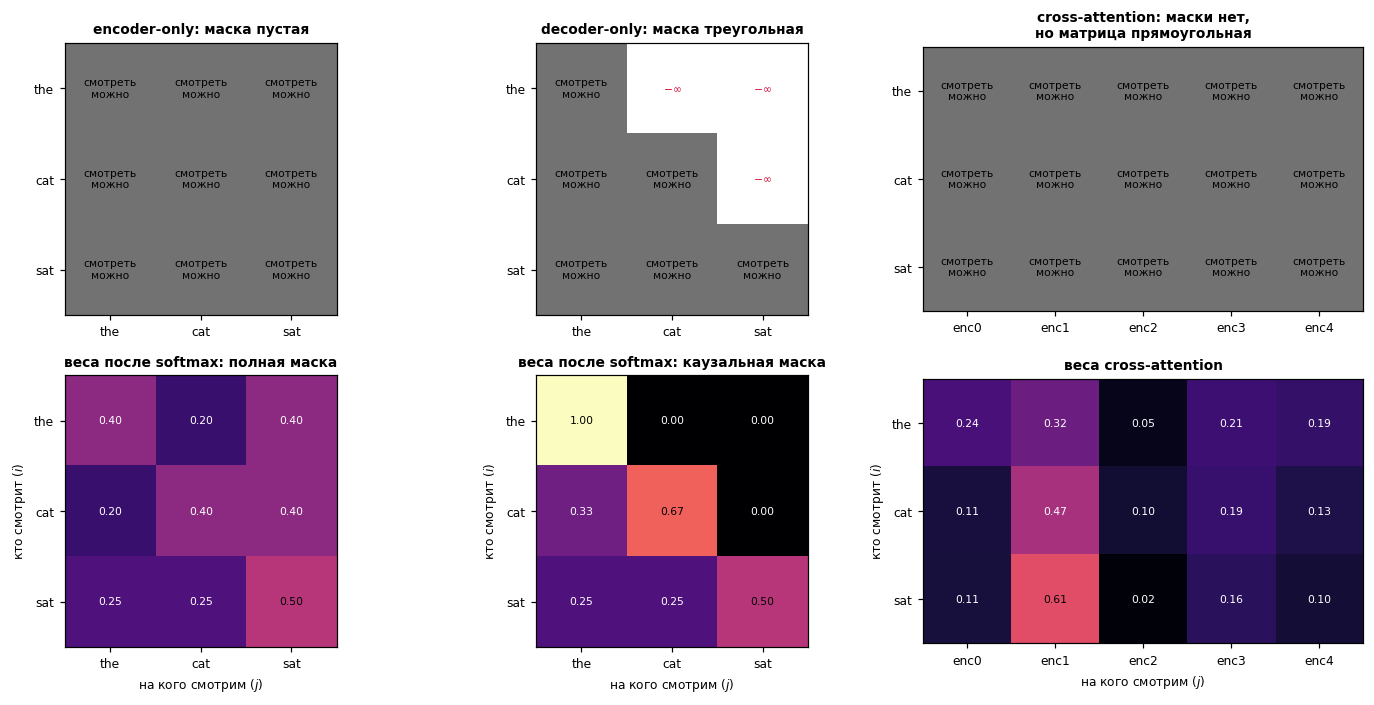

scores = QK^T / sqrt(d_k):
 [[0.707 0.    0.707]
 [0.    0.707 0.707]
 [0.707 0.707 1.414]]

строка «the» при полной маске:     [0.401 0.198 0.401]  сумма = 1.0
строка «the» при каузальной маске: [1. 0. 0.]  сумма = 1.0

состояния h_i = sum_j a_ij v_j
  полная      [[0.802, 0.599], [0.599, 0.802], [0.752, 0.752]]
  каузальная  [[1.0, 0.0], [0.33, 0.67], [0.752, 0.752]]


In [18]:
# ── Три маски и одна формула на трёх игрушечных токенах ──────────────
TOY = ["the", "cat", "sat"]
X = np.array([[1.0, 0.0], [0.0, 1.0], [1.0, 1.0]])   # «эмбеддинги» трёх токенов
Q = K = V = X                                         # W_Q = W_K = W_V = I, чтобы всё было видно руками
d_k = X.shape[1]

scores = Q @ K.T / np.sqrt(d_k)                       # шаги 1-2 из сноски


def softmax_rows(S):
    S = S - S.max(axis=1, keepdims=True)
    E = np.exp(S)
    return E / E.sum(axis=1, keepdims=True)


M_full = np.zeros((3, 3))                             # encoder-only: маски нет
M_causal = np.triu(np.full((3, 3), -np.inf), 1)       # decoder-only и self-attn декодера
A_full = softmax_rows(scores + M_full)
A_causal = softmax_rows(scores + M_causal)

# cross-attention: запросы от декодера (3 позиции), ключи от энкодера (5 позиций)
rng_toy = np.random.default_rng(SEED)
X_enc = rng_toy.standard_normal((5, d_k))
A_cross = softmax_rows(Q @ X_enc.T / np.sqrt(d_k))    # маски нет вовсе

fig, axes = plt.subplots(2, 3, figsize=(13, 6.4))
panels = [
    (axes[0, 0], np.where(np.isfinite(M_full), 1.0, 0.0), "encoder-only: маска пустая",
     TOY, TOY),
    (axes[0, 1], np.where(np.isfinite(M_causal), 1.0, 0.0), "decoder-only: маска треугольная",
     TOY, TOY),
    (axes[0, 2], np.ones((3, 5)), "cross-attention: маски нет,\nно матрица прямоугольная",
     [f"enc{j}" for j in range(5)], TOY),
]
for ax, mat, title, xt, yt in panels:
    ax.imshow(mat, cmap="Greys", vmin=0, vmax=1.6)
    ax.set_title(title, fontsize=9, fontweight="bold")
    ax.set_xticks(range(mat.shape[1])); ax.set_xticklabels(xt, fontsize=8)
    ax.set_yticks(range(mat.shape[0])); ax.set_yticklabels(yt, fontsize=8)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, "смотреть\nможно" if mat[i, j] else r"$-\infty$",
                    ha="center", va="center", fontsize=7,
                    color="black" if mat[i, j] else "crimson")

for ax, A, title, xt in [
    (axes[1, 0], A_full, "веса после softmax: полная маска", TOY),
    (axes[1, 1], A_causal, "веса после softmax: каузальная маска", TOY),
    (axes[1, 2], A_cross, "веса cross-attention", [f"enc{j}" for j in range(5)]),
]:
    im = ax.imshow(A, cmap="magma", vmin=0, vmax=1)
    ax.set_title(title, fontsize=9, fontweight="bold")
    ax.set_xticks(range(A.shape[1])); ax.set_xticklabels(xt, fontsize=8)
    ax.set_yticks(range(A.shape[0])); ax.set_yticklabels(TOY, fontsize=8)
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            ax.text(j, i, f"{A[i, j]:.2f}", ha="center", va="center", fontsize=7,
                    color="w" if A[i, j] < 0.5 else "k")
    ax.set_xlabel("на кого смотрим ($j$)", fontsize=8)
    ax.set_ylabel("кто смотрит ($i$)", fontsize=8)

plt.tight_layout()
plt.show()

print("scores = QK^T / sqrt(d_k):\n", np.round(scores, 3))
print("\nстрока «the» при полной маске:    ", np.round(A_full[0], 3), " сумма =", A_full[0].sum())
print("строка «the» при каузальной маске:", np.round(A_causal[0], 3), " сумма =", A_causal[0].sum())
print("\nсостояния h_i = sum_j a_ij v_j")
for name, A in (("полная", A_full), ("каузальная", A_causal)):
    print(f"  {name:11s}", np.round(A @ V, 3).tolist())